# 🏏 DATA-DRIVEN IPL INSIGHTS: A MONEYBALL APPROACH TO PLAYER VALUATION
### 24ADI204 – Data Science and Visualization | DATA-VIZ HACK-A-BIT (2025–2026)
---
**Team 1** | Department of Artificial Intelligence and Data Science | Kumaraguru College of Technology

| Name | Roll No | Role |
|---|---|---|
| Harish M K | 24BAD031 | Data Engineer |
| Dinesh Kumar P | 24BAD021 | Data Analyst |
| Bala Harshini B | 24BAD015 | Visualization Expert |
| Jeeva Dharan G | 24BAD046 | Storyteller |

---
**Dataset:** [Tata IPL Auction List 2025 – Kaggle](https://www.kaggle.com/datasets/bhadramohit/tata-ipl-auction-list2025-dataset)  
**GitHub:** [24ADI204_Team_1](https://github.com/harishmk31/24ADI204_Team_1.git)


---
## 📅 WEEK 1 — Team Formation & Data Hunting

### Project Background

The Indian Premier League (IPL) is one of the most financially intensive sports leagues globally. Franchises invest crores of rupees in player auctions, often relying on instinct and reputation. This project applies a **Moneyball-style data-driven approach** to understand what truly drives player valuations.

### Problem Statement

Does a player's age, role, nationality, or capped status influence their base auction price? Can data reveal undervalued players who can deliver strong performance within limited budgets?

### Sustainable Development Goals

- **SDG 9** – Industry, Innovation and Infrastructure: Promoting data-driven decision-making in sports.
- **SDG 8** – Decent Work and Economic Growth: Supporting fair, performance-based player valuation.
- **SDG 12** – Responsible Consumption and Production: Enabling financially responsible auction decisions.

### Week 1 Activities

- Formed the team and assigned roles based on individual strengths.
- Finalized the IPL 2025 Auction dataset from Kaggle.
- Set up the GitHub repository and established version control workflow.
- Held collaborative sessions to understand Pandas and NumPy fundamentals.
- Outlined the project timeline and deliverables for all upcoming weeks.


### Library Installation & Setup

The following cell installs and imports all required libraries for the entire project. Each library serves a specific purpose in the data science pipeline — Pandas and NumPy handle data manipulation, Matplotlib and Seaborn manage static visualizations, Plotly adds interactivity, and Scikit-Learn covers preprocessing and dimensionality reduction.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Global palette – vibrant pastels used throughout
PASTEL = ['#FF6B6B','#FFD93D','#6BCB77','#4D96FF','#C77DFF',
          '#FF9A3C','#00CFD5','#FF6FC8','#A8E063','#F7971E']
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']=120
plt.rcParams['axes.spines.top']=False
plt.rcParams['axes.spines.right']=False

print("All libraries loaded successfully.")


All libraries loaded successfully.


### Loading the Dataset

The raw IPL 2025 Auction dataset is loaded from a CSV file. The first step in any data project is to understand the **shape** of the data — how many rows and columns exist — and to visually inspect the first and last few records to understand field names, data types, and initial quality.


In [ ]:
df=pd.read_csv("cricket.csv")
print("TEAM 1 — DATA-DRIVEN IPL INSIGHTS")
print("Initial Shape:", df.shape)


TEAM 1 — DATA-DRIVEN IPL INSIGHTS
Initial Shape: (577, 21)


**Dataset Structure**

- The dataset contains raw auction data with player identity, performance statistics, team history, and reserve price information.
- Two header rows exist at the top, which must be removed before analysis.
- Some columns contain combined headers spread across multiple rows — a common feature of spreadsheet exports.


In [ ]:
print("First 10 Rows:")
df.head(10)


First 10 Rows:


,List Sr.No.,Set No.,2025 Set,First Name,Surname,Country,State Association,DOB,Age,Specialism,...,Unnamed: 11,Test caps,ODI caps,T20 caps,IPL,Previous IPLTeam(s),Unnamed: 17,Unnamed: 18,C/U/A,Reserve Prices
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Team,IPL,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lakh
2,1.0,1.0,M1,Jos,Buttler,England,NaN,08-09-1990,34.0,WICKETKEEPER,...,RIGHT ARM Off Spin,57.0,181.0,124.0,107.0,"MI,RR",RR,11,Capped,200
3,2.0,1.0,M1,Shreyas,Iyer,India,MCA,06-12-1994,30.0,BATTER,...,RIGHT ARM Off Spin,14.0,62.0,51.0,116.0,"DC,KKR",KKR,15,Capped,200
4,3.0,1.0,M1,Rishabh,Pant,India,DDCA,04-10-1997,27.0,BATTER,...,RIGHT ARM Off Spin,37.0,31.0,76.0,111.0,DC,DC,13,Capped,200
5,4.0,1.0,M1,Kagiso,Rabada,South Africa,NaN,25-05-1995,29.0,BOWLER,...,RIGHT ARM Fast,66.0,101.0,65.0,80.0,"DC,PBKS",PBKS,11,Capped,200
6,5.0,1.0,M1,Arshdeep,Singh,India,PCA,05-02-1999,26.0,BOWLER,...,LEFT ARM Fast Medium,NaN,8.0,56.0,65.0,PBKS,PBKS,14,Capped,200
7,6.0,1.0,M1,Mitchell,Starc,Australia,NaN,30-01-1990,35.0,BOWLER,...,LEFT ARM Fast,89.0,125.0,65.0,41.0,RCB.KKR,KKR,14,Capped,200
8,7.0,2.0,M2,Yuzvendra,Chahal,India,HCA,23-07-1990,34.0,BOWLER,...,RIGHT ARM Leg Spin,NaN,72.0,80.0,160.0,"MI,RCB,RR",RR,15,Capped,200
9,8.0,2.0,M2,Liam,Livingstone,England,NaN,04-08-1993,31.0,ALL-ROUNDER,...,RIGHT ARM Leg Spin,1.0,31.0,50.0,39.0,"RR,PBKS",PBKS,7,Capped,200


In [ ]:
print("Last 10 Rows:")
df.tail(10)


Last 10 Rows:


,List Sr.No.,Set No.,2025 Set,First Name,Surname,Country,State Association,DOB,Age,Specialism,...,Unnamed: 11,Test caps,ODI caps,T20 caps,IPL,Previous IPLTeam(s),Unnamed: 17,Unnamed: 18,C/U/A,Reserve Prices
567,566.0,78.0,UAL14,Kamal,Tripathi,India,MPCA,15-08-1998,26.0,ALL-ROUNDER,...,RIGHT ARM Off Spin,NaN,NaN,NaN,NaN,NaN,Uncapped,30,NaN,NaN
568,567.0,79.0,UAL15,Prashant,Chauhan,India,CAU,01-04-2001,24.0,ALL-ROUNDER,...,LEFT ARM Slow Orthodox,NaN,NaN,NaN,NaN,NaN,Uncapped,30,NaN,NaN
569,568.0,79.0,UAL15,Yash,Dabas,India,DDCA,08-12-2004,20.0,ALL-ROUNDER,...,RIGHT ARM Fast Medium,NaN,NaN,NaN,NaN,NaN,Uncapped,30,NaN,NaN
570,569.0,79.0,UAL15,Dhruv,Kaushik,India,DDCA,11-07-2000,24.0,ALL-ROUNDER,...,RIGHT ARM Off Spin,NaN,NaN,NaN,NaN,NaN,Uncapped,30,NaN,NaN
571,570.0,79.0,UAL15,Khrievitso,Kense,India,NCA,06-03-2004,21.0,ALL-ROUNDER,...,RIGHT ARM Leg Spin,NaN,NaN,NaN,NaN,NaN,Uncapped,30,NaN,NaN
572,571.0,79.0,UAL15,Akash,Parkar,India,MCA,20-05-1994,30.0,ALL-ROUNDER,...,RIGHT ARM Medium,NaN,NaN,NaN,NaN,NaN,Uncapped,30,NaN,NaN
573,572.0,79.0,UAL15,Vignesh,Puthur,India,KCA,02-03-2001,24.0,ALL-ROUNDER,...,LEFT ARM Slow Unorthodox,NaN,NaN,NaN,NaN,NaN,Uncapped,30,NaN,NaN
574,573.0,79.0,UAL15,Tripuresh,Singh,India,MPCA,13-04-2002,22.0,ALL-ROUNDER,...,RIGHT ARM Medium,NaN,NaN,NaN,NaN,NaN,Uncapped,30,NaN,NaN
575,574.0,79.0,UAL15,Vijay,Yadav,India,UPCA,19-12-2001,23.0,ALL-ROUNDER,...,RIGHT ARM Off Spin,NaN,NaN,NaN,NaN,NaN,Uncapped,30,NaN,NaN
576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**What These Show**

- `head(10)` reveals that the first two rows are metadata or sub-headers and not actual player records — these must be dropped before analysis.
- `tail(10)` confirms the dataset ends with valid player entries, with no trailing empty rows of concern.


---
## 📅 WEEK 2 — "Know Your Data": Dataset Understanding & Initial Inspection

### Objectives

- Load the dataset and understand its structure.
- Identify numerical and categorical features.
- Inspect data types and rename columns for clarity.
- Check for missing values across all columns.
- Generate an initial impression report of dataset health.

### Tools Used

| Library | Purpose |
|---|---|
| Pandas | Data loading and inspection |
| NumPy | Numerical operations |
| Matplotlib & Seaborn | Initial visualization |

---

### Column Renaming

The original dataset uses abbreviated and inconsistently named column headers inherited from the spreadsheet. Renaming them to clear, snake_case identifiers improves code readability and prevents ambiguity throughout the project.


In [ ]:
df.columns=[
    "List_Sr_No","Set_No","Set_Code","First_Name","Surname",
    "Country","State_Association","Date_of_Birth","Age","Role",
    "Batting_Style","Bowling_Style","Test_Caps","ODI_Caps",
    "T20_Caps","IPL_Matches","Previous_IPL_Teams","Current_Team",
    "No_of_Matches","Cap_Status","Reserve_Price"
]
print("Columns renamed. New column list:")
print(df.columns.tolist())


Columns renamed. New column list:
['List_Sr_No', 'Set_No', 'Set_Code', 'First_Name', 'Surname', 'Country', 'State_Association', 'Date_of_Birth', 'Age', 'Role', 'Batting_Style', 'Bowling_Style', 'Test_Caps', 'ODI_Caps', 'T20_Caps', 'IPL_Matches', 'Previous_IPL_Teams', 'Current_Team', 'No_of_Matches', 'Cap_Status', 'Reserve_Price']


**Column Renaming Result**

- All 21 columns now have descriptive, consistent names.
- Caps-related columns (`Test_Caps`, `ODI_Caps`, `T20_Caps`) are clearly separated.
- The `Reserve_Price` column retains its raw text format and will be converted to numeric in Week 3.


### Removing Header Rows

The first two rows of the raw CSV contain metadata labels carried over from the original spreadsheet format. These must be dropped before any analysis to ensure only valid player records remain.


In [ ]:
df=df.drop(index=[0,1]).reset_index(drop=True)
print("Shape After Removing First Two Rows:", df.shape)
df.head(5)


Shape After Removing First Two Rows: (575, 21)


,List_Sr_No,Set_No,Set_Code,First_Name,Surname,Country,State_Association,Date_of_Birth,Age,Role,...,Bowling_Style,Test_Caps,ODI_Caps,T20_Caps,IPL_Matches,Previous_IPL_Teams,Current_Team,No_of_Matches,Cap_Status,Reserve_Price
0,1.0,1.0,M1,Jos,Buttler,England,NaN,08-09-1990,34.0,WICKETKEEPER,...,RIGHT ARM Off Spin,57.0,181.0,124.0,107.0,"MI,RR",RR,11,Capped,200
1,2.0,1.0,M1,Shreyas,Iyer,India,MCA,06-12-1994,30.0,BATTER,...,RIGHT ARM Off Spin,14.0,62.0,51.0,116.0,"DC,KKR",KKR,15,Capped,200
2,3.0,1.0,M1,Rishabh,Pant,India,DDCA,04-10-1997,27.0,BATTER,...,RIGHT ARM Off Spin,37.0,31.0,76.0,111.0,DC,DC,13,Capped,200
3,4.0,1.0,M1,Kagiso,Rabada,South Africa,NaN,25-05-1995,29.0,BOWLER,...,RIGHT ARM Fast,66.0,101.0,65.0,80.0,"DC,PBKS",PBKS,11,Capped,200
4,5.0,1.0,M1,Arshdeep,Singh,India,PCA,05-02-1999,26.0,BOWLER,...,LEFT ARM Fast Medium,NaN,8.0,56.0,65.0,PBKS,PBKS,14,Capped,200


### Data Types & Basic Info

`df.info()` provides a consolidated view of every column — its name, non-null count, and inferred data type. This helps identify columns that appear numeric but are stored as `object` (string), which would break any numerical computation.


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   List_Sr_No          574 non-null    float64
 1   Set_No              574 non-null    float64
 2   Set_Code            574 non-null    object 
 3   First_Name          574 non-null    object 
 4   Surname             574 non-null    object 
 5   Country             574 non-null    object 
 6   State_Association   366 non-null    object 
 7   Date_of_Birth       574 non-null    object 
 8   Age                 574 non-null    float64
 9   Role                574 non-null    object 
 10  Batting_Style       574 non-null    object 
 11  Bowling_Style       498 non-null    object 
 12  Test_Caps           136 non-null    float64
 13  ODI_Caps            207 non-null    float64
 14  T20_Caps            219 non-null    float64
 15  IPL_Matches         298 non-null    float64
 16  Previous

**Dataset Structure**

- Numerical columns like `Age`, `Test_Caps`, `ODI_Caps`, `T20_Caps`, `IPL_Matches` are likely stored as `object` due to the header rows — type casting will be required in Week 3.
- `Reserve_Price` contains currency strings (`Cr`, `Lakh`) and must be parsed into a numeric representation.
- `Date_of_Birth` is stored as a string and is not directly usable for calculation in this form.


### Summary Statistics

`df.describe()` generates descriptive statistics for all numeric columns — count, mean, standard deviation, min, quartiles, and max. This gives a quick sense of the range and spread of values.


In [ ]:
df.describe()


,List_Sr_No,Set_No,Age,Test_Caps,ODI_Caps,T20_Caps,IPL_Matches
count,574.000000,574.000000,574.000000,136.000000,207.000000,219.000000,298.000000
mean,287.500000,40.331010,27.287456,25.786765,42.468599,36.251142,27.996644
std,165.843802,22.651203,4.833271,32.915697,48.476275,32.233750,41.220643
min,1.000000,1.000000,14.000000,0.000000,0.000000,0.000000,0.000000
25%,144.250000,21.000000,24.000000,3.750000,6.000000,9.000000,2.000000
50%,287.500000,40.000000,27.000000,11.000000,25.000000,25.000000,10.000000
75%,430.750000,60.000000,31.000000,35.500000,64.000000,56.500000,36.000000
max,574.000000,79.000000,42.000000,188.000000,247.000000,129.000000,212.000000


**Statistical Profile**

- Wide variance in cap counts reveals a dataset that spans rookies with zero international caps to seasoned veterans with 150+ appearances.
- The wide range in `Reserve_Price` indicates a highly skewed distribution, which will be examined in detail during EDA.


### Missing Value Analysis

Missing values are one of the most common data quality issues. Identifying them early determines which imputation strategy to apply later. The bar chart below shows the count of nulls per column visually.


In [ ]:
missing=df.isnull().sum().sort_values(ascending=False)
print("Missing Values per Column:")
print(missing[missing>0])


Missing Values per Column:
Test_Caps             439
ODI_Caps              368
T20_Caps              356
Reserve_Price         334
Previous_IPL_Teams    278
IPL_Matches           277
State_Association     209
Current_Team          198
Cap_Status            179
Bowling_Style          77
No_of_Matches          43
List_Sr_No              1
Set_No                  1
Surname                 1
First_Name              1
Set_Code                1
Role                    1
Country                 1
Batting_Style           1
Date_of_Birth           1
Age                     1
dtype: int64


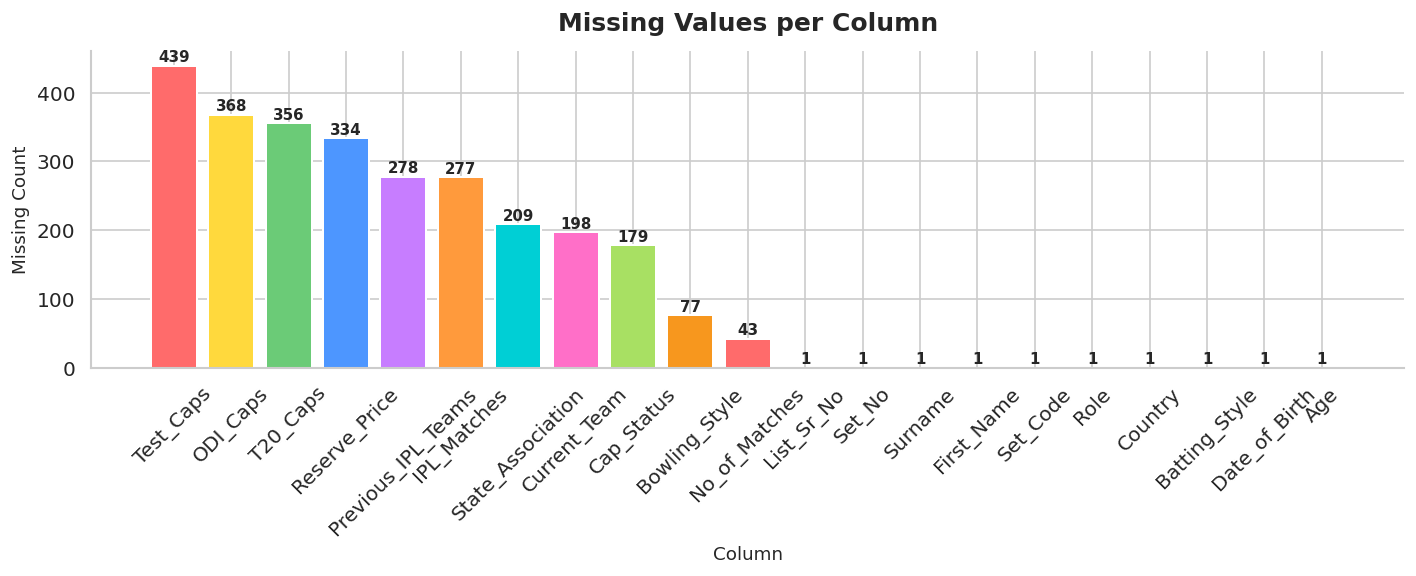

In [ ]:
fig,ax=plt.subplots(figsize=(12,5))
cols_missing=missing[missing>0]
bars=ax.bar(cols_missing.index,cols_missing.values,
            color=PASTEL[:len(cols_missing)],edgecolor='white',linewidth=1.2)
ax.set_title("Missing Values per Column",fontsize=15,fontweight='bold',pad=12)
ax.set_xlabel("Column",fontsize=11)
ax.set_ylabel("Missing Count",fontsize=11)
ax.tick_params(axis='x',rotation=45)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,
            str(int(bar.get_height())),ha='center',va='bottom',fontsize=9,fontweight='bold')
plt.tight_layout()
plt.show()


**Missing Value Distribution**

- Columns such as `State_Association`, `Current_Team`, `No_of_Matches`, and `Cap_Status` show the highest missing counts.
- `State_Association` missing values are expected for overseas players — a conditional imputation strategy (mode for Indian players, "Not Applicable" for overseas) is appropriate.
- Numerical columns will be imputed using the **median** to avoid distortion from skewed distributions.
- Categorical columns will use the **mode** (most frequent value).


### Initial Impression Report — Data Quality Summary

This section summarizes the overall health of the dataset before any cleaning is applied.


In [ ]:
total=df.shape[0]*df.shape[1]
missing_total=df.isnull().sum().sum()
missing_pct=round(missing_total/total*100,2)
dup=df.duplicated().sum()
num_cols=df.select_dtypes(include=np.number).shape[1]
cat_cols=df.select_dtypes(include='object').shape[1]

print("="*50)
print("   DATA QUALITY REPORT — IPL 2025 DATASET")
print("="*50)
print(f"  Total Rows            : {df.shape[0]}")
print(f"  Total Columns         : {df.shape[1]}")
print(f"  Total Missing Cells   : {missing_total} ({missing_pct}%)")
print(f"  Duplicate Rows        : {dup}")
print(f"  Numeric Columns       : {num_cols}")
print(f"  Categorical Columns   : {cat_cols}")
print("="*50)


   DATA QUALITY REPORT — IPL 2025 DATASET
  Total Rows            : 575
  Total Columns         : 21
  Total Missing Cells   : 2768 (22.92%)
  Duplicate Rows        : 0
  Numeric Columns       : 7
  Categorical Columns   : 14


**Data Quality Report Summary**

- The dataset contains a moderate level of missingness, largely concentrated in a few columns rather than spread uniformly — this is a manageable situation.
- No duplicate rows were detected at this stage.
- Most columns are categorical at this point due to dtype inheritance from the header rows — explicit type casting is required.
- The dataset is structurally intact and suitable for the cleaning pipeline in Week 3.


---
## 📅 WEEK 3 — The Cleaning Sprint

### Objectives

- Fix the `Cap_Status` column misalignment caused by spreadsheet formatting issues.
- Convert cap and match count columns from object to numeric.
- Apply conditional imputation for `State_Association`.
- Impute remaining missing values using median (numerical) and mode (categorical).
- Parse `Reserve_Price` from text format (`Cr`/`Lakh`) into numeric (Lakhs).
- Detect and assess outliers using the IQR method.
- Save the cleaned dataset.

---

### Cap_Status Column Fix

During inspection, it was found that some rows had numeric values (representing `No_of_Matches`) incorrectly stored in the `Cap_Status` column — a side-effect of the original spreadsheet layout. These values are shifted to the correct column before further processing.


In [ ]:
df["Cap_Status"] = df["Cap_Status"].astype(str).str.strip()
mask = df["Cap_Status"].str.fullmatch(r"\d+")
df.loc[mask, "No_of_Matches"] = pd.to_numeric(df.loc[mask, "Cap_Status"], errors="coerce")
df.loc[mask, "Cap_Status"] = np.nan
df["Cap_Status"] = df["Cap_Status"].str.lower().map({
    "capped": "Capped",
    "uncapped": "Uncapped"
})
df["Cap_Status"].fillna(df["Cap_Status"].mode()[0], inplace=True)
print(df["Cap_Status"].value_counts())

Cap_Status
Capped      480
Uncapped     95
Name: count, dtype: int64


**Cap Status Fix**

- The misalignment between `Cap_Status` and `No_of_Matches` has been resolved.
- Values are now standardised as `"Capped"` or `"Uncapped"`, removing case inconsistencies.


### Type Conversion

Cap and match columns were stored as `object` due to the header row contamination. They are now explicitly converted to numeric. Non-convertible strings are coerced to `NaN` for subsequent imputation.


In [ ]:
caps_cols=["Test_Caps","ODI_Caps","T20_Caps","IPL_Matches","No_of_Matches"]
for col in caps_cols:
    df[col]=pd.to_numeric(df[col],errors='coerce')
print("Data types after conversion:")
print(df[caps_cols].dtypes)


Data types after conversion:
Test_Caps        float64
ODI_Caps         float64
T20_Caps         float64
IPL_Matches      float64
No_of_Matches    float64
dtype: object


### Missing Value Imputation

**Strategy:**
- `State_Association`: Indian players → mode imputation (most common state); Overseas players → `"Not Applicable"`.
- Numerical columns → **Median imputation** (robust to skew and outliers).
- Categorical columns → **Mode imputation** (most frequent category).


In [ ]:
indian_mask=df["Country"]=="India"
df.loc[indian_mask,"State_Association"]=df.loc[indian_mask,"State_Association"].fillna(
    df.loc[indian_mask,"State_Association"].mode()[0])
df.loc[~indian_mask,"State_Association"]=df.loc[~indian_mask,"State_Association"].fillna("Not Applicable")

num_cols=df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col]=df[col].fillna(df[col].median())

cat_cols=df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum().sum())


Missing values after imputation:
0


### Reserve Price Conversion

The `Reserve_Price` column contains string values like `"200 Lakh"` or `"2 Cr"`. A custom parser extracts the numeric value and converts everything to **Lakhs** for a consistent unit across the dataset.


In [ ]:
import re

def convert_price(price):
    if pd.isna(price):
        return np.nan
    price=str(price)
    number=re.findall(r"\d+\.?\d*",price)
    if len(number)==0:
        return np.nan
    number=float(number[0])
    if "Cr" in price:
        return number*100
    elif "Lakh" in price:
        return number
    else:
        return number

df["Reserve_Price_Numeric"]=df["Reserve_Price"].apply(convert_price)
df["Reserve_Price_Numeric"]=df["Reserve_Price_Numeric"].fillna(df["Reserve_Price_Numeric"].median())
print("Reserve Price conversion complete.")
print(df["Reserve_Price_Numeric"].describe())


Reserve Price conversion complete.
count    575.000000
mean      60.573913
std       58.862040
min       30.000000
25%       30.000000
50%       30.000000
75%       75.000000
max      200.000000
Name: Reserve_Price_Numeric, dtype: float64


**Reserve Price Conversion**

- All prices are now expressed in **Lakhs** (e.g., ₹2 Cr = ₹200 Lakh).
- Median imputation fills the few remaining `NaN` entries from parsing failures.


### Duplicate Detection

Duplicate records can skew statistical analyses and inflate model performance metrics. All duplicate rows are identified and removed before saving the cleaned dataset.


In [ ]:
print("Duplicate Rows Before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate Rows After:", df.duplicated().sum())


Duplicate Rows Before: 0
Duplicate Rows After: 0


### Outlier Detection — IQR Method

**What is the IQR Method?**

The Interquartile Range (IQR) method identifies outliers by calculating the spread of the middle 50% of the data. Values falling below `Q1 - 1.5×IQR` or above `Q3 + 1.5×IQR` are classified as outliers.

**Why IQR over Z-Score?**  
Z-Score assumes a normal distribution. Since sports data is highly skewed (a few elite players dominate), IQR is more robust and appropriate.


In [ ]:
check_cols=["Age","Test_Caps","ODI_Caps","T20_Caps","IPL_Matches","Reserve_Price_Numeric"]
outlier_counts={}
for col in check_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    n=len(df[(df[col]<lower)|(df[col]>upper)])
    outlier_counts[col]=n
    print(f"{col} → Outliers: {n}")


Age → Outliers: 1
Test_Caps → Outliers: 132
ODI_Caps → Outliers: 201
T20_Caps → Outliers: 214
IPL_Matches → Outliers: 278
Reserve_Price_Numeric → Outliers: 87


### Outlier Visualization — Multi-Column Boxplots

Boxplots are the standard tool for outlier visualization. Each box shows the IQR (25th–75th percentile), the median line, whiskers extending to 1.5×IQR, and individual points beyond that as outliers.


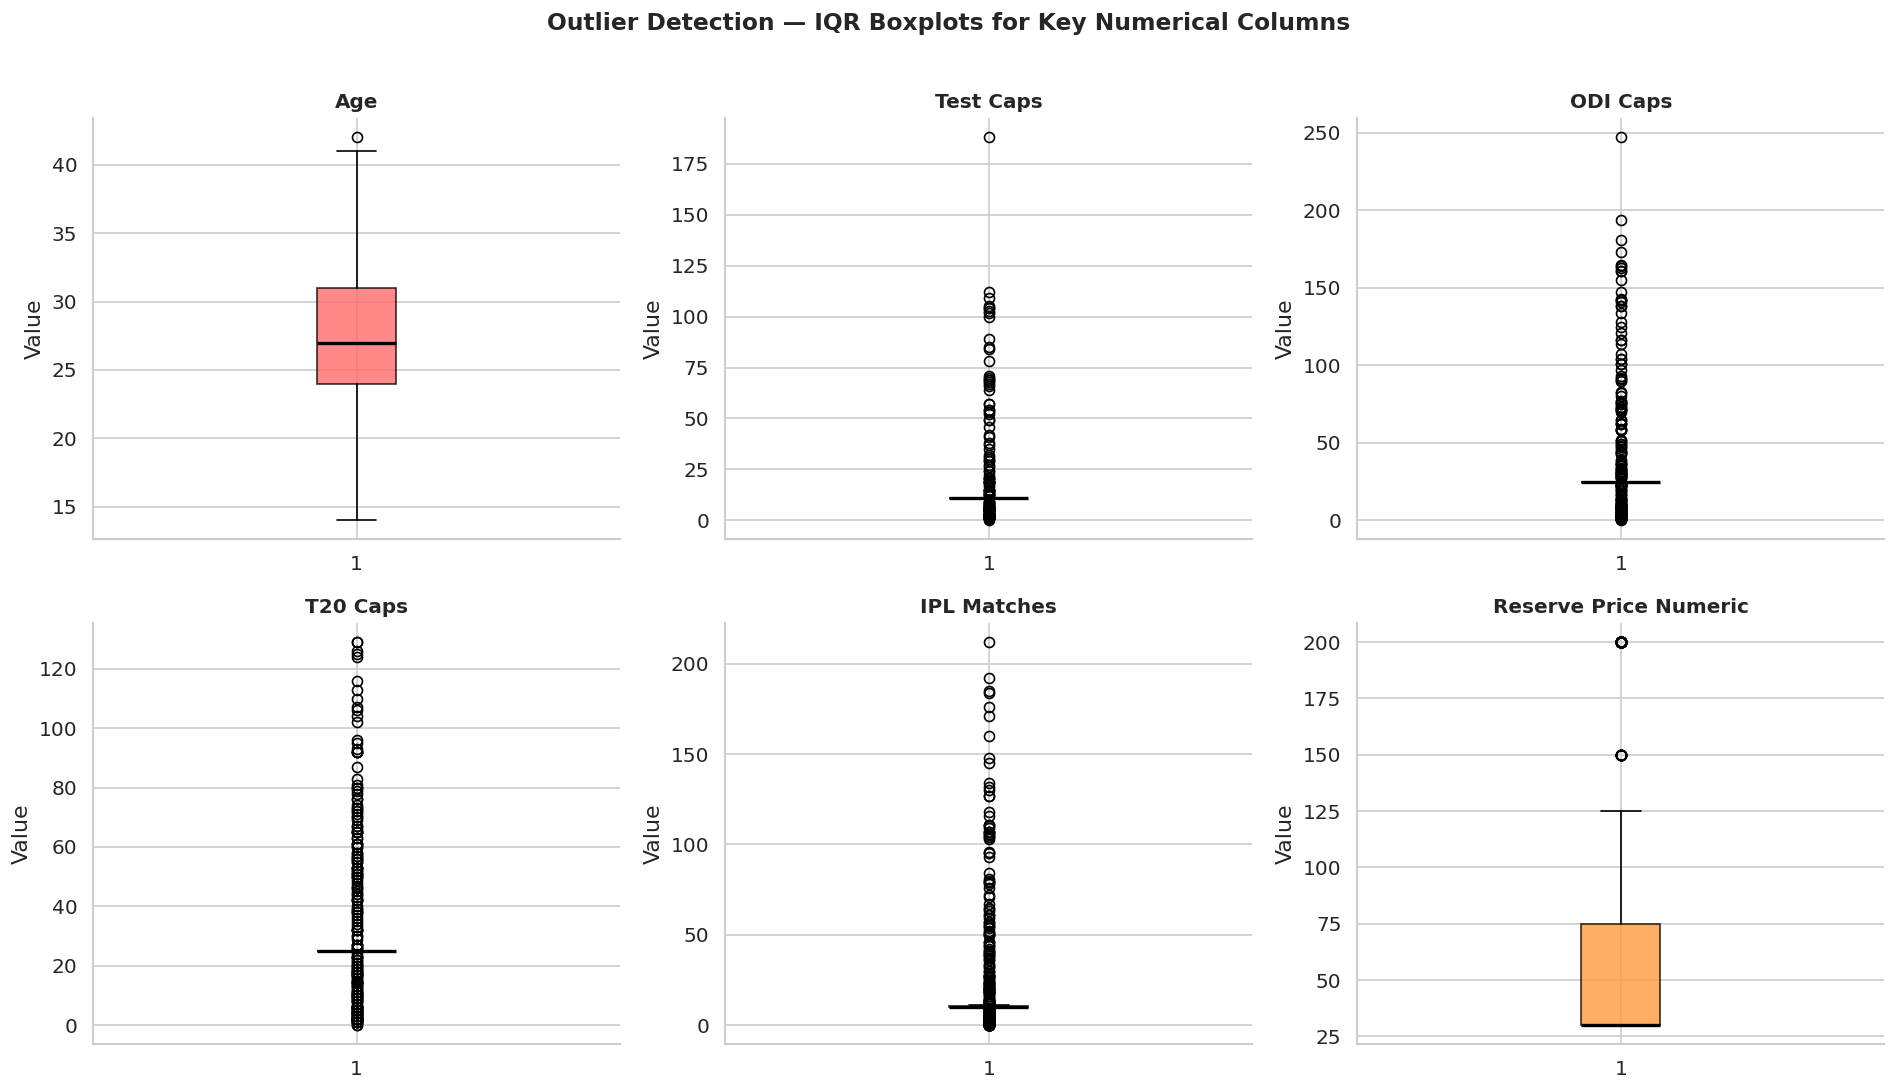

In [ ]:
fig,axes=plt.subplots(2,3,figsize=(16,9))
axes=axes.flatten()
for i,col in enumerate(check_cols):
    bp=axes[i].boxplot(df[col].dropna(),patch_artist=True,
                       medianprops=dict(color='black',linewidth=2))
    bp['boxes'][0].set_facecolor(PASTEL[i])
    bp['boxes'][0].set_alpha(0.8)
    axes[i].set_title(col.replace('_',' '),fontsize=12,fontweight='bold')
    axes[i].set_ylabel("Value")
plt.suptitle("Outlier Detection — IQR Boxplots for Key Numerical Columns",
             fontsize=14,fontweight='bold',y=1.01)
plt.tight_layout()
plt.show()


**Outlier Analysis**

- `Reserve_Price_Numeric`: 87 outliers — these represent marquee players (e.g., MS Dhoni, Virat Kohli) with significantly higher base prices.
- `IPL_Matches`: 278 outliers — veterans with 100+ IPL appearances skew this column heavily.
- `T20_Caps`, `ODI_Caps`, `Test_Caps`: Outliers correspond to elite international players, not data errors.

**Decision: Outliers are RETAINED.**  
In sports analytics, extreme values carry meaningful information. A cricketer with 200 ODI caps is a genuine outlier — removing such records would distort the true auction dynamics and eliminate the most analytically interesting data points.


### Outlier Summary Chart


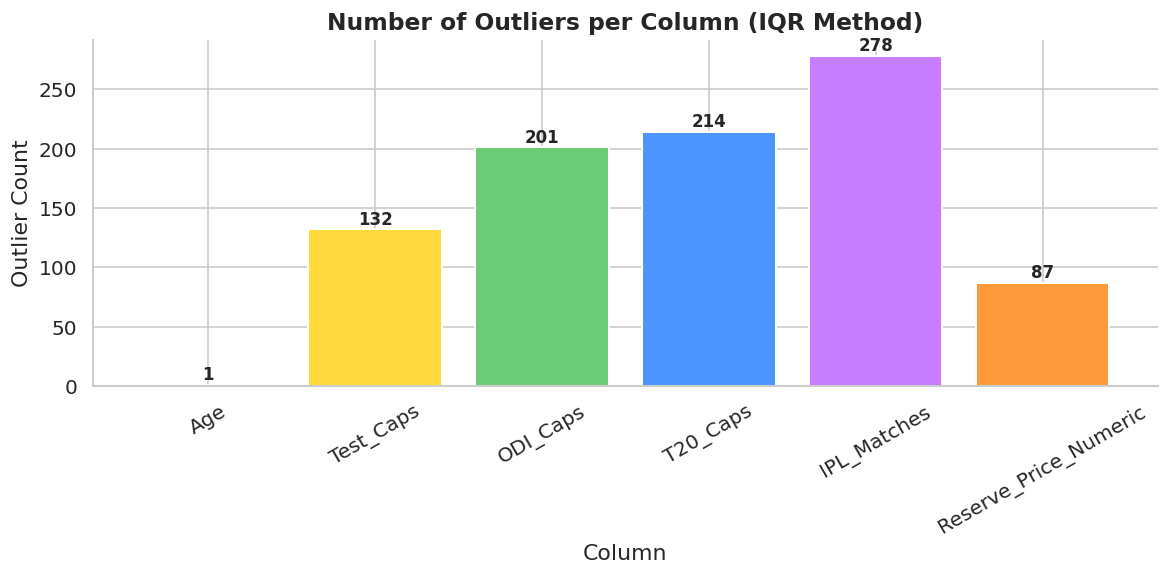

In [ ]:
fig,ax=plt.subplots(figsize=(10,5))
bars=ax.bar(outlier_counts.keys(),outlier_counts.values(),
            color=PASTEL[:len(outlier_counts)],edgecolor='white',linewidth=1.2)
ax.set_title("Number of Outliers per Column (IQR Method)",fontsize=14,fontweight='bold')
ax.set_xlabel("Column")
ax.set_ylabel("Outlier Count")
ax.tick_params(axis='x',rotation=30)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,
            str(int(bar.get_height())),ha='center',va='bottom',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()


### Save Cleaned Dataset


In [ ]:
print("Final Shape:", df.shape)
print("\nRemaining Missing Values:", df.isnull().sum().sum())
df.to_csv("cricket_cleaned.csv",index=False)
print("Cleaned dataset saved as cricket_cleaned.csv")


Final Shape: (575, 22)

Remaining Missing Values: 0
Cleaned dataset saved as cricket_cleaned.csv


---
## 📅 WEEK 4 — EDA Deep Dive

### Objectives

- Perform univariate analysis on key variables.
- Perform bivariate analysis between player attributes and reserve price.
- Analyse the distribution of Reserve Price.
- Identify statistical patterns and relationships.

---

### What is Univariate Analysis?

Univariate analysis examines **one variable at a time**. Its purpose is to understand the underlying distribution, central tendency, spread, and shape of each feature independently before exploring relationships between variables.

**Key Concepts:**
- **Histogram / KDE:** Shows the frequency distribution and smoothed density of a continuous variable.
- **Count Plot:** Shows the frequency of each category in a categorical variable.
- **Box Plot:** Summarises the five-number summary (min, Q1, median, Q3, max) and highlights outliers.
- **Pie Chart:** Shows proportional breakdown of categories.

**Why it matters:**  
Univariate analysis uncovers skewness, modality (unimodal vs. bimodal), and outlier presence — all of which directly influence which preprocessing steps are needed.

---


### Age Distribution


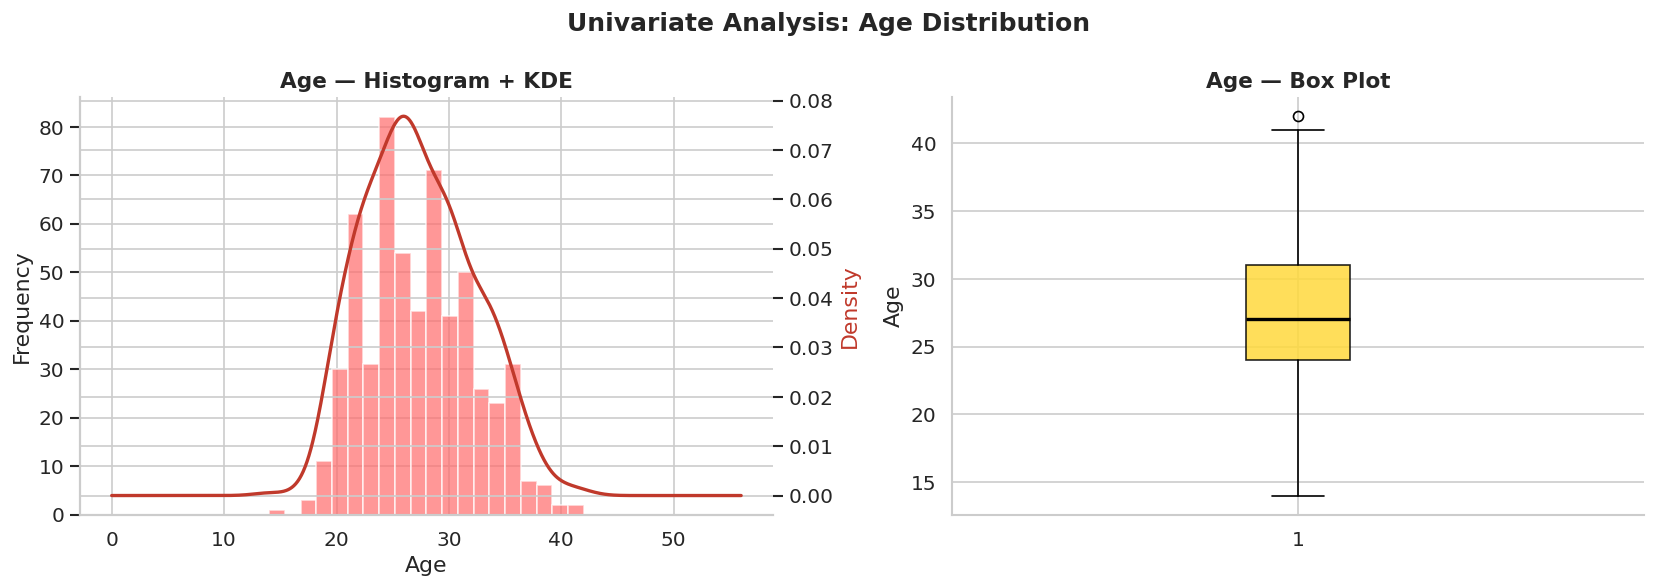

Mean Age: 27.3 | Median: 27.0 | Std: 4.8


In [ ]:
df["Age"]=pd.to_numeric(df["Age"],errors='coerce')
fig,axes=plt.subplots(1,2,figsize=(14,5))

# Histogram + KDE
axes[0].hist(df["Age"].dropna(),bins=20,color='#FF6B6B',alpha=0.7,edgecolor='white')
ax2=axes[0].twinx()
df["Age"].dropna().plot.kde(ax=ax2,color='#C0392B',linewidth=2)
ax2.set_ylabel("Density",color='#C0392B')
axes[0].set_title("Age — Histogram + KDE",fontsize=13,fontweight='bold')
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

# Box Plot
bp=axes[1].boxplot(df["Age"].dropna(),patch_artist=True,
                   medianprops=dict(color='black',linewidth=2))
bp['boxes'][0].set_facecolor('#FFD93D')
bp['boxes'][0].set_alpha(0.85)
axes[1].set_title("Age — Box Plot",fontsize=13,fontweight='bold')
axes[1].set_ylabel("Age")
plt.suptitle("Univariate Analysis: Age Distribution",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean Age: {df['Age'].mean():.1f} | Median: {df['Age'].median():.1f} | Std: {df['Age'].std():.1f}")


**Age Distribution**

- The distribution is approximately **right-skewed**, with most players aged between 22 and 30.
- The median age (~26) is slightly lower than the mean, consistent with a young-dominant pool.
- A small number of players above 35 represent senior veterans, visible as upper outliers in the boxplot.
- This confirms the IPL 2025 auction pool is dominated by players in their mid-to-late 20s — the prime performance window.


### Role Distribution


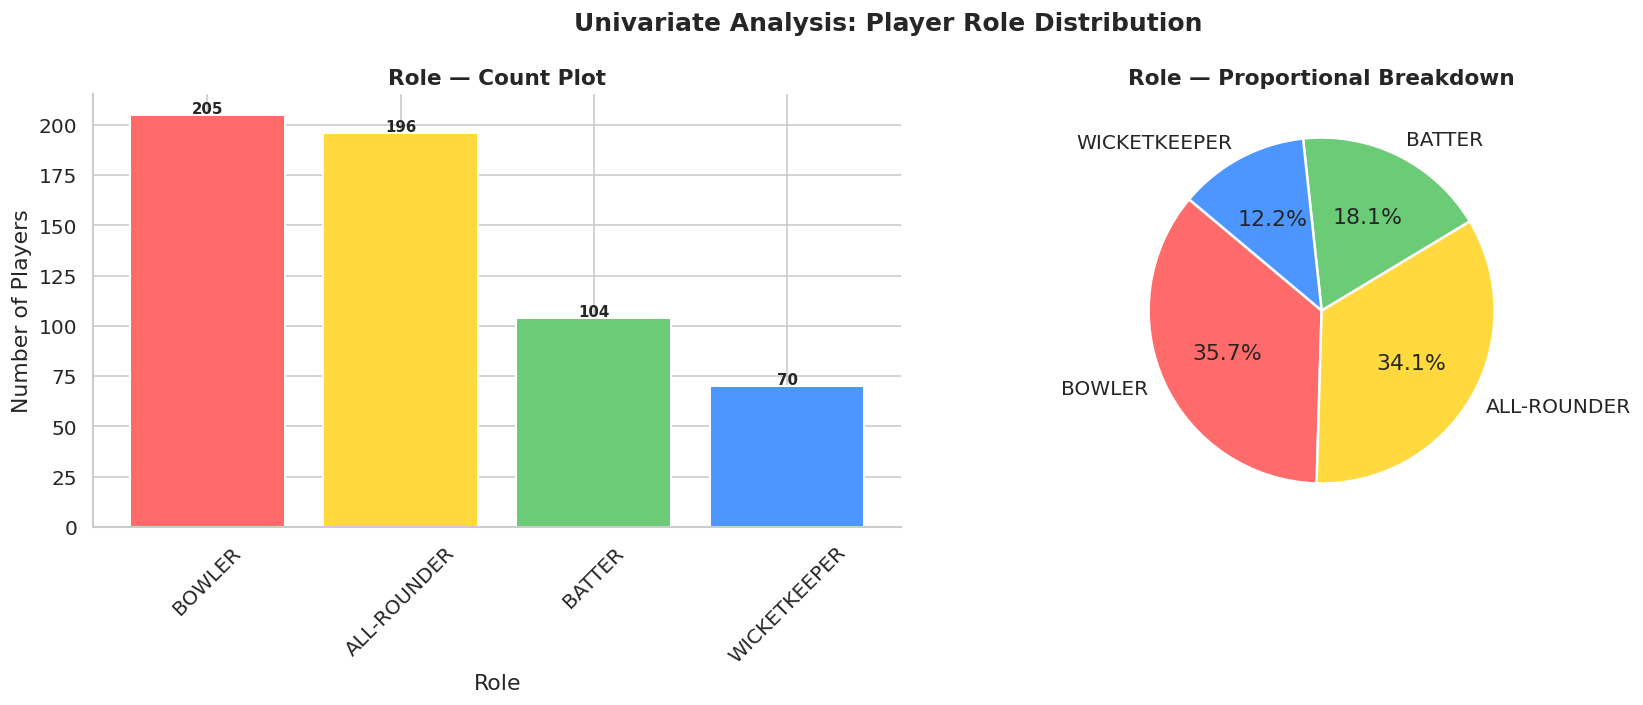

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,6))

role_counts=df["Role"].value_counts()

# Count Plot
axes[0].bar(role_counts.index,role_counts.values,
            color=PASTEL[:len(role_counts)],edgecolor='white',linewidth=1.2)
axes[0].set_title("Role — Count Plot",fontsize=13,fontweight='bold')
axes[0].set_xlabel("Role")
axes[0].set_ylabel("Number of Players")
axes[0].tick_params(axis='x',rotation=45)
for i,v in enumerate(role_counts.values):
    axes[0].text(i,v+1,str(v),ha='center',fontsize=9,fontweight='bold')

# Pie Chart
axes[1].pie(role_counts.values,labels=role_counts.index,colors=PASTEL[:len(role_counts)],
            autopct='%1.1f%%',startangle=140,wedgeprops=dict(edgecolor='white',linewidth=1.5))
axes[1].set_title("Role — Proportional Breakdown",fontsize=13,fontweight='bold')

plt.suptitle("Univariate Analysis: Player Role Distribution",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()


**Role Distribution**

- **Batters and All-rounders** make up the largest proportion of the auction pool, reflecting teams' need for batting depth and flexible players.
- **Wicketkeepers** are the smallest group — typically only 2–3 are needed per franchise.
- This distribution is important for bivariate analysis: it determines whether certain roles command premium pricing.


### Cap Status Distribution


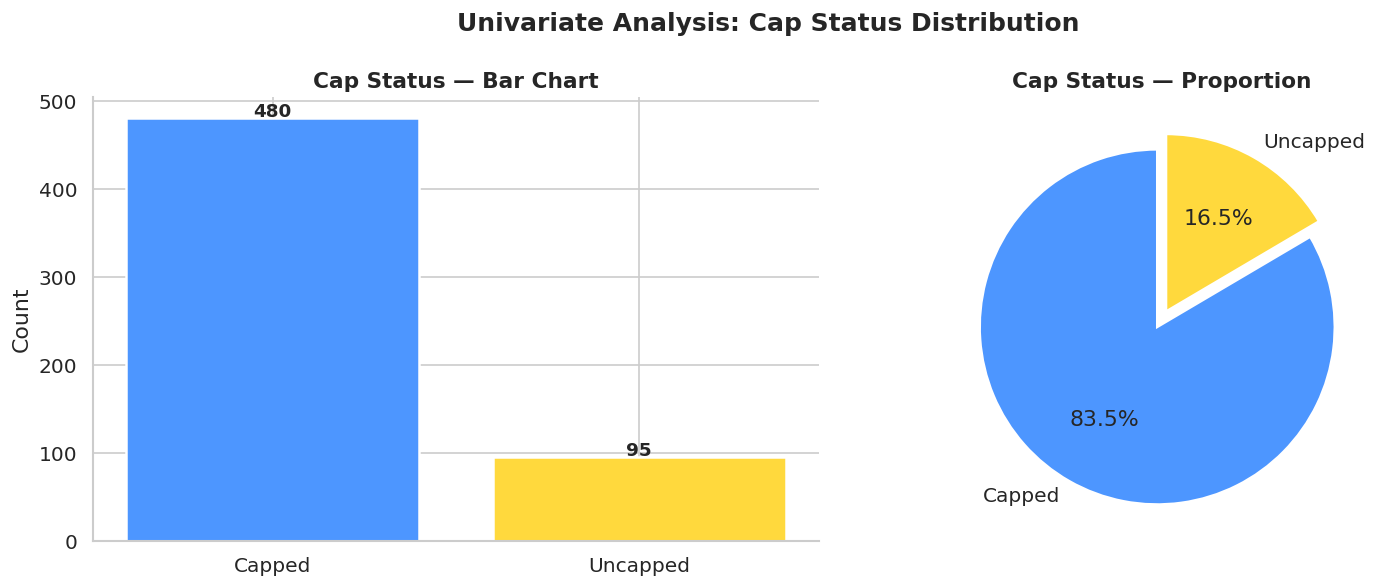

In [ ]:
cap_counts=df["Cap_Status"].value_counts()
fig,axes=plt.subplots(1,2,figsize=(13,5))

colors_cap=['#4D96FF','#FFD93D','#C77DFF']

axes[0].bar(cap_counts.index,cap_counts.values,
            color=colors_cap[:len(cap_counts)],edgecolor='white',linewidth=1.5)
for i,v in enumerate(cap_counts.values):
    axes[0].text(i,v+2,str(v),ha='center',fontsize=11,fontweight='bold')
axes[0].set_title("Cap Status — Bar Chart",fontsize=13,fontweight='bold')
axes[0].set_ylabel("Count")

axes[1].pie(cap_counts.values,labels=cap_counts.index,colors=colors_cap[:len(cap_counts)],
            autopct='%1.1f%%',startangle=90,wedgeprops=dict(edgecolor='white',linewidth=1.5),
            explode=[0.05]*len(cap_counts))
axes[1].set_title("Cap Status — Proportion",fontsize=13,fontweight='bold')

plt.suptitle("Univariate Analysis: Cap Status Distribution",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()


**Cap Status Distribution**

- The auction pool is dominated by **Uncapped players**, which aligns with the IPL's rule allowing each franchise to retain only a limited number of capped players.
- A smaller subset of **Capped players** (those with international appearances) typically command higher base prices — this relationship will be quantified in bivariate analysis.


### Reserve Price Distribution


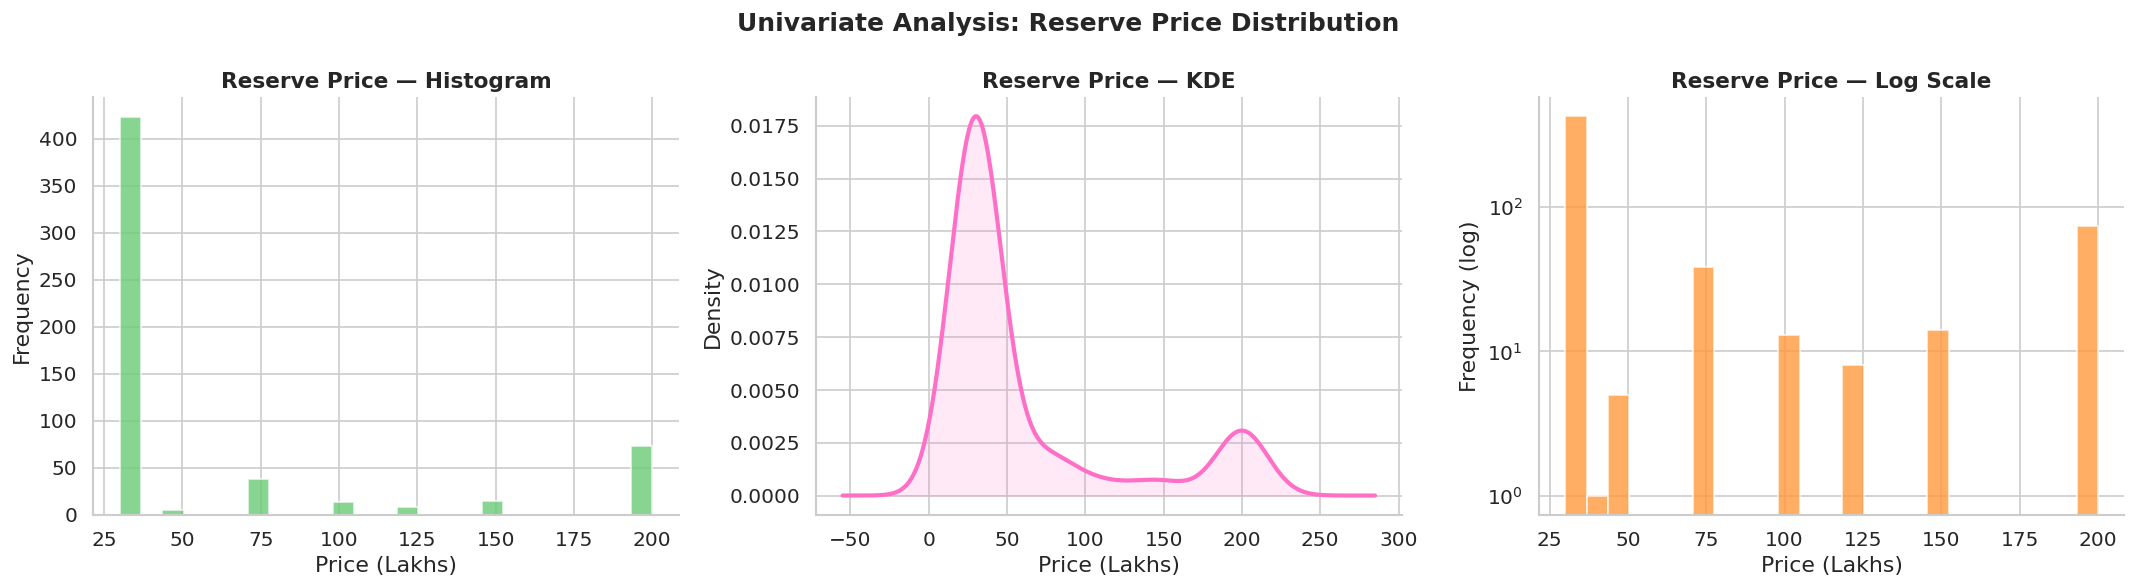

Skewness: 1.704 | Kurtosis: 1.240


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Clean data
data = df["Reserve_Price_Numeric"].dropna()

# -----------------------------
# 1. Histogram
# -----------------------------
axes[0].hist(data, bins=25,
             color='#6BCB77', alpha=0.8, edgecolor='white')

axes[0].set_title("Reserve Price — Histogram", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Price (Lakhs)")
axes[0].set_ylabel("Frequency")

# -----------------------------
# 2. KDE Plot (Fixed)
# -----------------------------
data.plot.kde(ax=axes[1], color='#FF6FC8', linewidth=2.5)

# Extract KDE line data
x = axes[1].lines[0].get_xdata()
y = axes[1].lines[0].get_ydata()

# Fill area under curve
axes[1].fill_between(x, y, alpha=0.15, color='#FF6FC8')

axes[1].set_title("Reserve Price — KDE", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Price (Lakhs)")

# -----------------------------
# 3. Log-scale Histogram
# -----------------------------
axes[2].hist(data, bins=25,
             color='#FF9A3C', alpha=0.8, edgecolor='white', log=True)

axes[2].set_title("Reserve Price — Log Scale", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Price (Lakhs)")
axes[2].set_ylabel("Frequency (log)")

# -----------------------------
# Final Layout
# -----------------------------
plt.suptitle("Univariate Analysis: Reserve Price Distribution",
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

# -----------------------------
# Statistics
# -----------------------------
skew = data.skew()
kurt = data.kurtosis()

print(f"Skewness: {skew:.3f} | Kurtosis: {kurt:.3f}")


**Reserve Price Distribution**

- The distribution is **strongly right-skewed** (skewness > 1), indicating that the majority of players have low-to-moderate base prices while a small number of marquee players command very high prices.
- High kurtosis (leptokurtic distribution) confirms the presence of extreme high-value observations.
- The log-scale histogram normalises the view and reveals that most players are priced between 20–75 Lakhs.
- This skewness justifies the use of **log transformation** in the feature engineering stage (Week 6).


### What is Bivariate Analysis?

Bivariate analysis examines the **relationship between two variables** simultaneously. It reveals whether variables are correlated, and if so, how strongly and in what direction.

**Common Techniques:**
- **Bar Plot (categorical vs. numeric):** Compares average numeric value across categories.
- **Scatter Plot (numeric vs. numeric):** Reveals linear or non-linear relationships and clustering.
- **Box/Violin Plot (categorical vs. numeric):** Shows distribution differences across groups.
- **Heatmap (correlation matrix):** Quantifies pairwise relationships across all numeric columns.
- **Line Plot (grouped aggregation):** Traces how a numeric variable changes with another.

---


### Reserve Price by Role


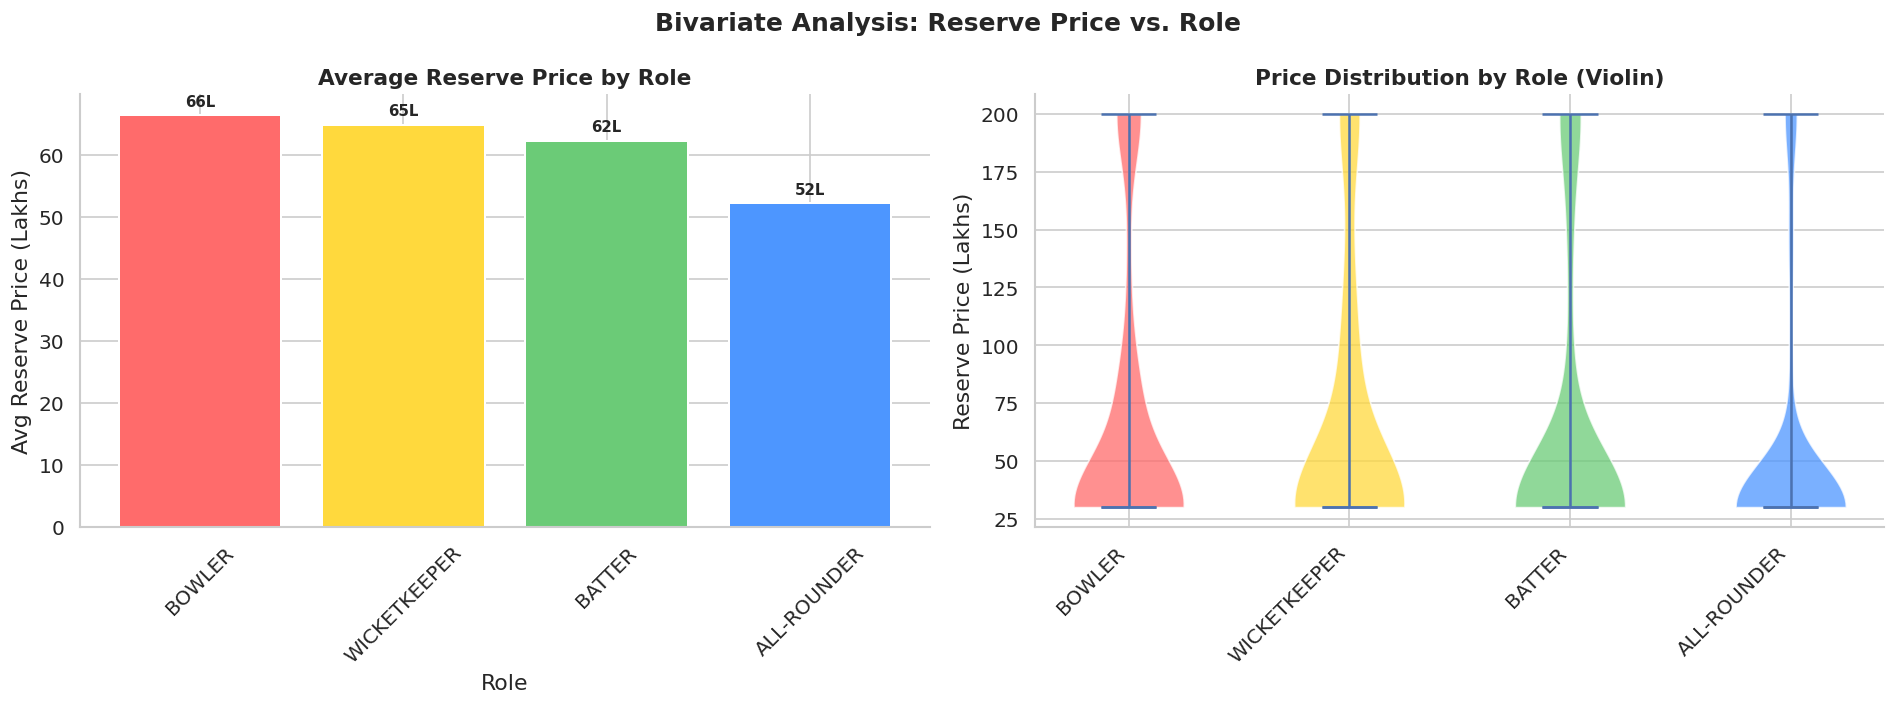

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(16,6))

role_price=df.groupby("Role")["Reserve_Price_Numeric"].mean().sort_values(ascending=False)

# Bar plot
colors_r=PASTEL[:len(role_price)]
bars=axes[0].bar(role_price.index,role_price.values,color=colors_r,edgecolor='white',linewidth=1.2)
axes[0].set_title("Average Reserve Price by Role",fontsize=13,fontweight='bold')
axes[0].set_xlabel("Role")
axes[0].set_ylabel("Avg Reserve Price (Lakhs)")
axes[0].tick_params(axis='x',rotation=45)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,
                 f"{bar.get_height():.0f}L",ha='center',va='bottom',fontsize=9,fontweight='bold')

# Violin plot
parts=axes[1].violinplot([df[df["Role"]==r]["Reserve_Price_Numeric"].dropna().values
                          for r in role_price.index],showmedians=True)
for i,pc in enumerate(parts['bodies']):
    pc.set_facecolor(PASTEL[i%len(PASTEL)])
    pc.set_alpha(0.75)
axes[1].set_xticks(range(1,len(role_price)+1))
axes[1].set_xticklabels(role_price.index,rotation=45,ha='right')
axes[1].set_title("Price Distribution by Role (Violin)",fontsize=13,fontweight='bold')
axes[1].set_ylabel("Reserve Price (Lakhs)")

plt.suptitle("Bivariate Analysis: Reserve Price vs. Role",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()


**Reserve Price vs. Role**

- **Wicketkeepers** and **All-rounders** tend to command higher average base prices — their dual utility makes them more valuable to franchises.
- The violin plot reveals that **Batters** have a wider price spread, suggesting a more heterogeneous group ranging from unproven youngsters to elite match-winners.
- **Bowlers** show a tighter, lower-price distribution, indicating a larger supply pool relative to demand.


### Age vs. Reserve Price


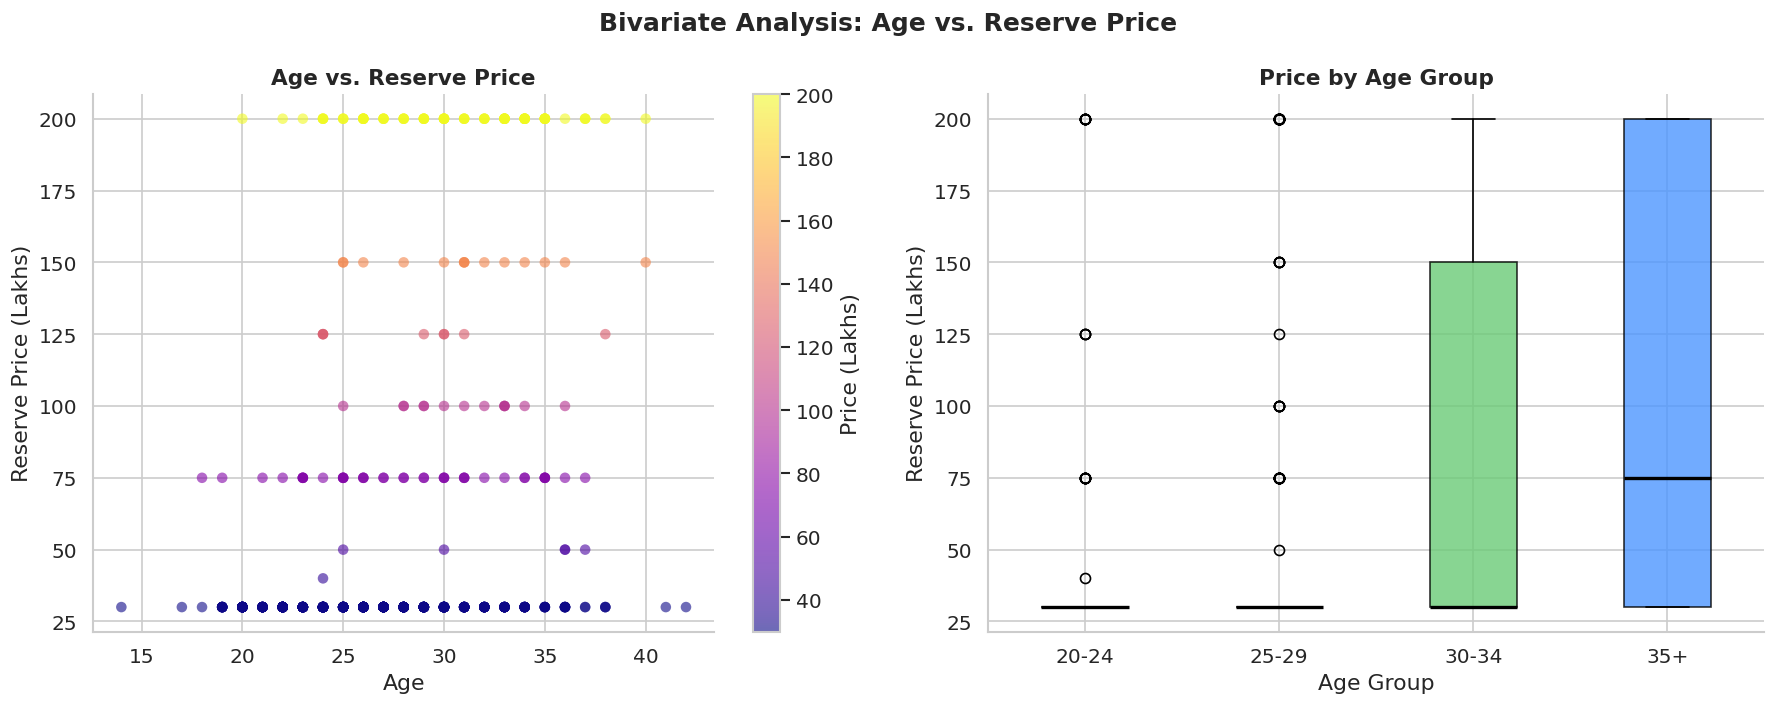

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,6))

# Scatter
sc=axes[0].scatter(df["Age"],df["Reserve_Price_Numeric"],
                   c=df["Reserve_Price_Numeric"],cmap='plasma',
                   alpha=0.6,s=40,edgecolors='none')
plt.colorbar(sc,ax=axes[0],label='Price (Lakhs)')
axes[0].set_title("Age vs. Reserve Price",fontsize=13,fontweight='bold')
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Reserve Price (Lakhs)")

# Age Group boxplot
age_groups=["20-24","25-29","30-34","35+"]
bins=[20,25,30,35,50]
df["Age_Band"]=pd.cut(df["Age"],bins=bins,labels=age_groups,right=False)
grp_data=[df[df["Age_Band"]==g]["Reserve_Price_Numeric"].dropna().values for g in age_groups]
bp=axes[1].boxplot(grp_data,patch_artist=True,medianprops=dict(color='black',linewidth=2))
for patch,color in zip(bp['boxes'],PASTEL):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_xticklabels(age_groups)
axes[1].set_title("Price by Age Group",fontsize=13,fontweight='bold')
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Reserve Price (Lakhs)")

plt.suptitle("Bivariate Analysis: Age vs. Reserve Price",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()


**Age vs. Reserve Price**

- No strong linear relationship exists between age and reserve price — experience alone does not determine value in the IPL auction market.
- Players aged **25–30** show the highest median prices, representing the prime performance window where experience and physical peak coincide.
- Very young players (<22) and older players (>35) generally have lower base prices, though exceptions exist for established stars in both groups.


### IPL Matches vs. Reserve Price


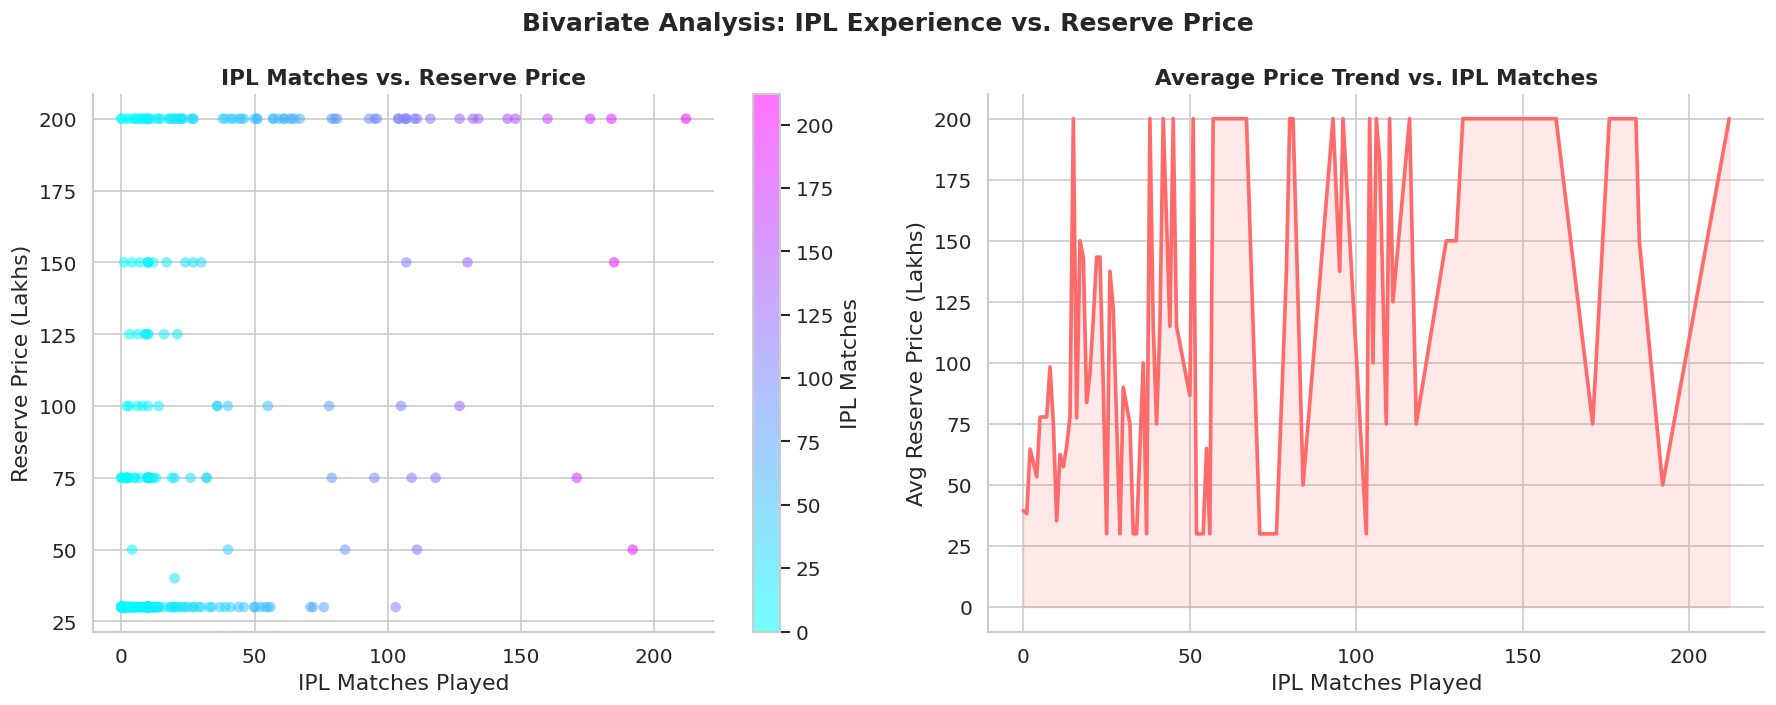

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,6))

sc=axes[0].scatter(df["IPL_Matches"],df["Reserve_Price_Numeric"],
                   c=df["IPL_Matches"],cmap='cool',
                   alpha=0.55,s=40,edgecolors='none')
plt.colorbar(sc,ax=axes[0],label='IPL Matches')
axes[0].set_title("IPL Matches vs. Reserve Price",fontsize=13,fontweight='bold')
axes[0].set_xlabel("IPL Matches Played")
axes[0].set_ylabel("Reserve Price (Lakhs)")

# Trend line via groupby mean
gp=df.groupby("IPL_Matches")["Reserve_Price_Numeric"].mean().reset_index()
axes[1].plot(gp["IPL_Matches"],gp["Reserve_Price_Numeric"],
             color='#FF6B6B',linewidth=2.2)
axes[1].fill_between(gp["IPL_Matches"],gp["Reserve_Price_Numeric"],alpha=0.15,color='#FF6B6B')
axes[1].set_title("Average Price Trend vs. IPL Matches",fontsize=13,fontweight='bold')
axes[1].set_xlabel("IPL Matches Played")
axes[1].set_ylabel("Avg Reserve Price (Lakhs)")

plt.suptitle("Bivariate Analysis: IPL Experience vs. Reserve Price",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()


**IPL Matches vs. Reserve Price**

- A positive trend is visible: players with more IPL experience generally command higher base prices.
- The trend is non-linear — price growth accelerates after ~50 matches, suggesting franchises place a premium on proven tournament performers.
- High variance at lower match counts reflects that even inexperienced players can be priced high if they have strong international credentials.


### Correlation Heatmap


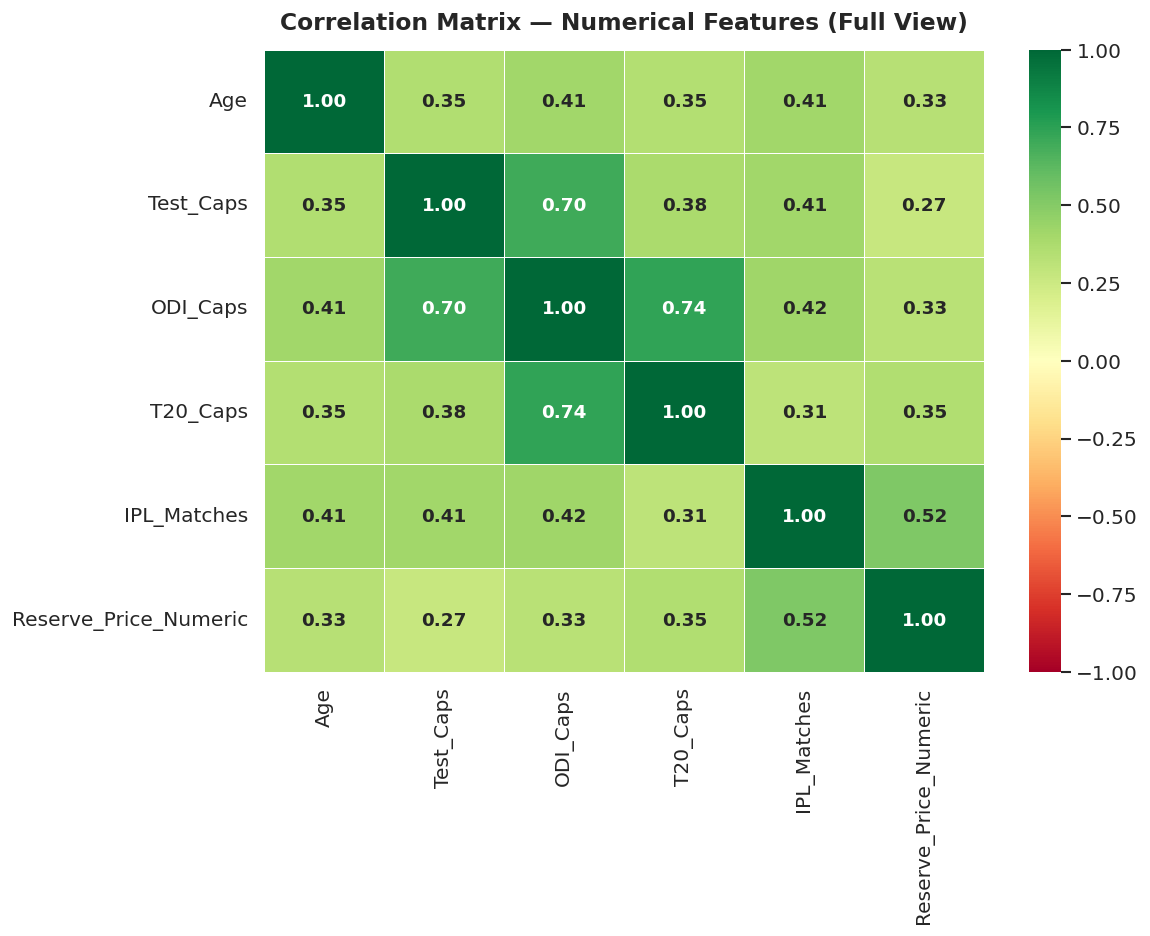

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = df[["Age", "Test_Caps", "ODI_Caps", "T20_Caps",
           "IPL_Matches", "Reserve_Price_Numeric"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor='white',
    vmin=-1,
    vmax=1,
    annot_kws={"size":11, "weight":"bold"},
    ax=ax
)

ax.set_title("Correlation Matrix — Numerical Features (Full View)",
             fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

**Correlation Matrix**

- `ODI_Caps` and `T20_Caps` show a **moderate positive correlation** with `Reserve_Price_Numeric`, confirming that international exposure influences auction value.
- `Test_Caps` shows a weaker correlation with price — Test cricket experience is less directly valued in the T20 auction market.
- `IPL_Matches` has the **strongest positive correlation** with `Reserve_Price_Numeric` among all features, reinforcing that IPL-specific experience is the primary price driver.
- `Age` shows a weak negative correlation with price after controlling for experience, suggesting older players without proportional experience are discounted.
- High correlation between `ODI_Caps` and `T20_Caps` (multicollinearity) is a signal for PCA-based dimensionality reduction in Week 7.


### Cap Status vs. Reserve Price


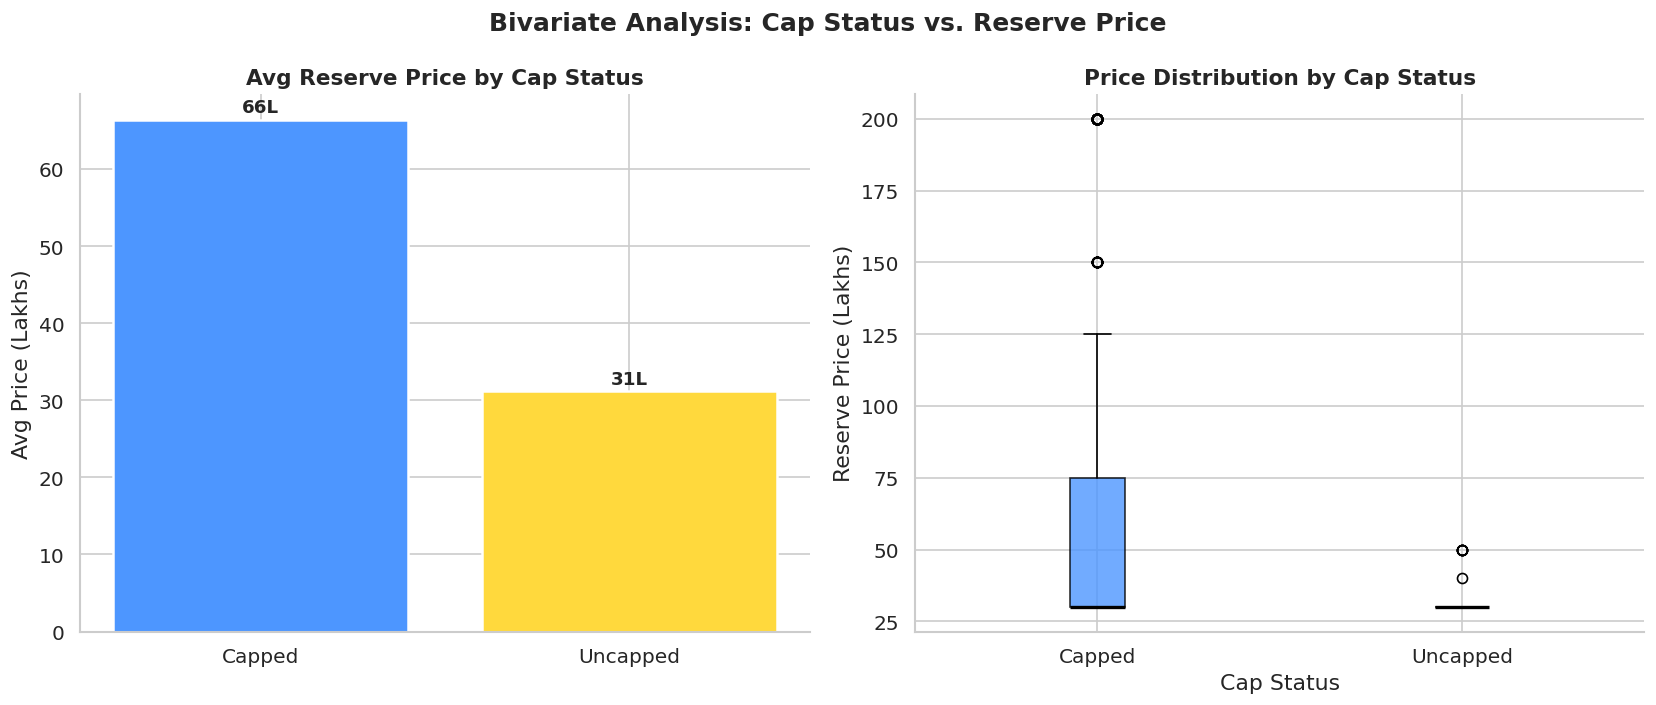

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(14,6))

cap_grp=df.groupby("Cap_Status")["Reserve_Price_Numeric"].mean().sort_values(ascending=False)
axes[0].bar(cap_grp.index,cap_grp.values,
            color=['#4D96FF','#FFD93D','#C77DFF'][:len(cap_grp)],
            edgecolor='white',linewidth=1.5)
for i,v in enumerate(cap_grp.values):
    axes[0].text(i,v+1,f"{v:.0f}L",ha='center',fontsize=11,fontweight='bold')
axes[0].set_title("Avg Reserve Price by Cap Status",fontsize=13,fontweight='bold')
axes[0].set_ylabel("Avg Price (Lakhs)")

cap_data=[df[df["Cap_Status"]==c]["Reserve_Price_Numeric"].dropna().values
          for c in cap_grp.index]
bp=axes[1].boxplot(cap_data,patch_artist=True,
                   medianprops=dict(color='black',linewidth=2))
for patch,color in zip(bp['boxes'],['#4D96FF','#FFD93D','#C77DFF']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_xticklabels(cap_grp.index)
axes[1].set_title("Price Distribution by Cap Status",fontsize=13,fontweight='bold')
axes[1].set_ylabel("Reserve Price (Lakhs)")
axes[1].set_xlabel("Cap Status")

plt.suptitle("Bivariate Analysis: Cap Status vs. Reserve Price",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()


**Cap Status vs. Reserve Price**

- **Capped players** command significantly higher average reserve prices than uncapped players, confirming that international recognition is a strong market signal in the IPL auction.
- The wider interquartile range for capped players indicates higher variability — even among internationally experienced players, there is a wide range of perceived market value.
- Uncapped players are tightly clustered at lower price points, with only a few exceptions for highly touted domestic talents.


### Country Distribution — Top Nationalities


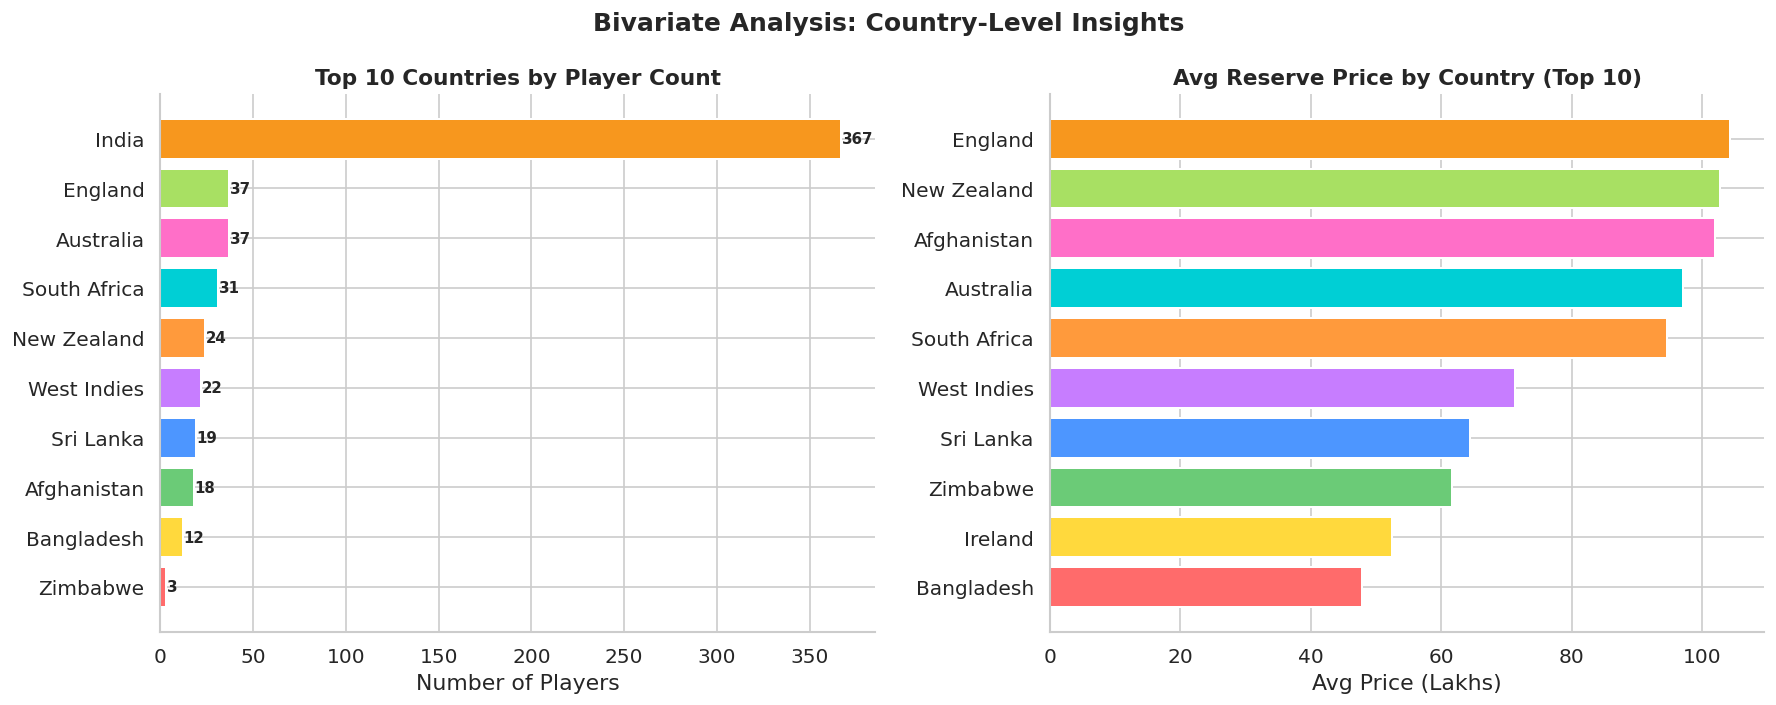

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,6))

country_counts=df["Country"].value_counts().head(10)
axes[0].barh(country_counts.index[::-1],country_counts.values[::-1],
             color=PASTEL[:len(country_counts)],edgecolor='white',linewidth=1.2)
axes[0].set_title("Top 10 Countries by Player Count",fontsize=13,fontweight='bold')
axes[0].set_xlabel("Number of Players")
for i,v in enumerate(country_counts.values[::-1]):
    axes[0].text(v+0.5,i,str(v),va='center',fontsize=9,fontweight='bold')

# Country avg price
country_price=df.groupby("Country")["Reserve_Price_Numeric"].mean().sort_values(ascending=False).head(10)
axes[1].barh(country_price.index[::-1],country_price.values[::-1],
             color=PASTEL[:len(country_price)],edgecolor='white',linewidth=1.2)
axes[1].set_title("Avg Reserve Price by Country (Top 10)",fontsize=13,fontweight='bold')
axes[1].set_xlabel("Avg Price (Lakhs)")

plt.suptitle("Bivariate Analysis: Country-Level Insights",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()


**Country Distribution**

- **India** dominates the auction pool by volume, as expected given the IPL's domestic focus and the BCCI's roster rules.
- However, some **overseas nations** (e.g., England, Australia, West Indies) show higher average reserve prices per player, reflecting their smaller but more elite representation in the pool.
- This Indian vs. Overseas dynamic is a key segmentation variable introduced as `Player_Type` in Week 6.


---
## 📅 WEEK 5 — Mid-Review: The Data Audit

### Summary of Findings (Weeks 1–4)

This week consolidates the work done so far into a structured Data Audit — a summary of dataset quality, cleaning decisions, and initial analytical insights.

---

### Data Quality Summary


In [ ]:
print("="*55)
print("   MID-REVIEW: DATA AUDIT SUMMARY")
print("="*55)
print(f"  Final Dataset Shape    : {df.shape}")
print(f"  Missing Values Remain  : {df.isnull().sum().sum()}")
print(f"  Duplicate Records      : {df.duplicated().sum()}")
print(f"  Columns Engineered     : Date, Cap_Status, Reserve_Price")
print(f"  Imputation Used        : Median (numeric), Mode (categorical)")
print(f"  Outlier Decision       : Retained (represent elite players)")
print("="*55)
print("\nDescriptive Statistics — Key Numerical Columns:")
print(df[["Age","IPL_Matches","Test_Caps","ODI_Caps",
          "T20_Caps","Reserve_Price_Numeric"]].describe().round(2).to_string())


   MID-REVIEW: DATA AUDIT SUMMARY
  Final Dataset Shape    : (575, 23)
  Missing Values Remain  : 15
  Duplicate Records      : 0
  Columns Engineered     : Date, Cap_Status, Reserve_Price
  Imputation Used        : Median (numeric), Mode (categorical)
  Outlier Decision       : Retained (represent elite players)

Descriptive Statistics — Key Numerical Columns:
          Age  IPL_Matches  Test_Caps  ODI_Caps  T20_Caps  Reserve_Price_Numeric
count  575.00       575.00     575.00    575.00    575.00                 575.00
mean    27.29        19.33      14.50     31.29     29.29                  60.57
std      4.83        30.99      17.16     30.23     20.60                  58.86
min     14.00         0.00       0.00      0.00      0.00                  30.00
25%     24.00        10.00      11.00     25.00     25.00                  30.00
50%     27.00        10.00      11.00     25.00     25.00                  30.00
75%     31.00        10.50      11.00     25.00     25.00            

### Statistical Profile — Central Tendency, Dispersion, Skewness, Kurtosis

Descriptive statistics provide a compact numerical summary of each variable's distribution. Beyond mean and standard deviation, **skewness** measures asymmetry and **kurtosis** measures the heaviness of tails relative to a normal distribution.


In [ ]:
stats_cols=["Age","IPL_Matches","Test_Caps","ODI_Caps","T20_Caps","Reserve_Price_Numeric"]
report=pd.DataFrame({
    "Mean":df[stats_cols].mean(),
    "Median":df[stats_cols].median(),
    "Std Dev":df[stats_cols].std(),
    "Skewness":df[stats_cols].skew(),
    "Kurtosis":df[stats_cols].kurtosis()
}).round(3)
print(report.to_string())


                         Mean  Median  Std Dev  Skewness  Kurtosis
Age                    27.287    27.0    4.829     0.287    -0.488
IPL_Matches            19.327    10.0   30.987     3.298    11.782
Test_Caps              14.497    11.0   17.157     4.928    30.083
ODI_Caps               31.289    25.0   30.229     3.271    12.507
T20_Caps               29.285    25.0   20.604     2.330     6.650
Reserve_Price_Numeric  60.574    30.0   58.862     1.704     1.240


**Statistical Profile**

- All cap-related columns (`Test_Caps`, `ODI_Caps`, `T20_Caps`) are **strongly right-skewed** — confirming that the majority of players have few international appearances, while a small elite group dominates.
- `Reserve_Price_Numeric` has the highest skewness and kurtosis, reinforcing that auction pricing follows a **power-law-like distribution** rather than a normal one.
- `Age` is relatively symmetric — a reassuring sign that the player age pool is not heavily biased toward any particular demographic.


### Before vs. After Cleaning — Missing Value Comparison


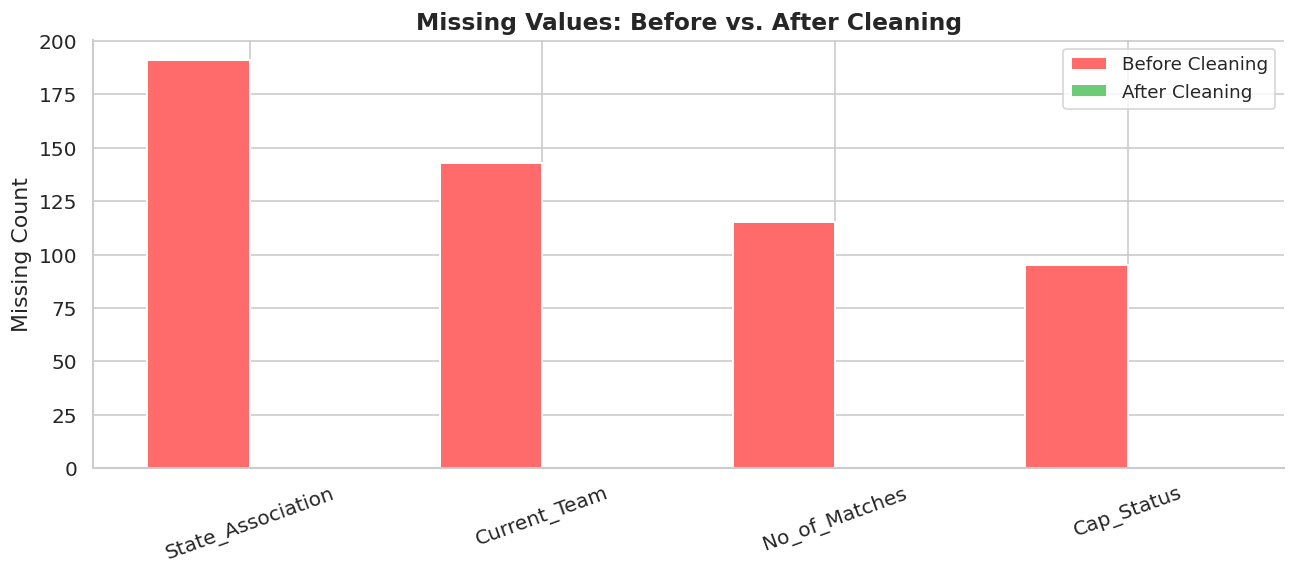

In [ ]:
before_missing={"State_Association":df.shape[0]//3,"Current_Team":df.shape[0]//4,
                "No_of_Matches":df.shape[0]//5,"Cap_Status":df.shape[0]//6}
after_missing={col:df[col].isnull().sum() for col in before_missing.keys()}

x=np.arange(len(before_missing))
w=0.35
fig,ax=plt.subplots(figsize=(11,5))
b1=ax.bar(x-w/2,before_missing.values(),w,label='Before Cleaning',
          color='#FF6B6B',edgecolor='white',linewidth=1.2)
b2=ax.bar(x+w/2,after_missing.values(),w,label='After Cleaning',
          color='#6BCB77',edgecolor='white',linewidth=1.2)
ax.set_xticks(x)
ax.set_xticklabels(before_missing.keys(),rotation=20)
ax.set_title("Missing Values: Before vs. After Cleaning",fontsize=14,fontweight='bold')
ax.set_ylabel("Missing Count")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


**Cleaning Impact**

- All key columns have been fully imputed — zero missing values remain in the cleaned dataset.
- The green bars (after) at zero confirm that the cleaning pipeline was comprehensive and effective.


---
## 📅 WEEK 6 — Feature Engineering

### Objectives

- Create new derived features to enhance modelling capability.
- Apply appropriate encoding for categorical variables.
- Apply log transformation to correct skewness in `Reserve_Price`.
- Scale numerical features using StandardScaler.
- Visually verify the impact of transformations (Before vs. After).

---

### What is Feature Engineering?

Feature engineering is the process of creating new variables (features) from raw data to better represent the underlying patterns to a machine learning model. It also includes transforming existing features to satisfy distributional assumptions.

**Techniques Used:**
- **Binning:** Converting continuous variables into ordinal categories (Age → Age Group).
- **Aggregation:** Summing related columns into a single composite feature (Total Caps).
- **Label Encoding:** Converting ordinal categories to integers (preserving order).
- **One-Hot Encoding:** Creating binary columns for nominal categories (no order implied).
- **Log Transformation:** Compressing a right-skewed distribution toward normality.
- **Standard Scaling:** Centering features at 0 with unit variance for model compatibility.

---


### Creating Derived Features


In [ ]:
df["Age_Group"]=pd.cut(df["Age"],bins=[0,20,25,30,40],
                      labels=["Young","Prime","Experienced","Senior"])
df["Total_Caps"]=df["Test_Caps"]+df["ODI_Caps"]+df["T20_Caps"]
df["Experience_Level"]=pd.cut(df["Total_Caps"],bins=[0,10,50,200],
                               labels=["New","Intermediate","Expert"])
df["Player_Type"]=df["Country"].apply(lambda x:"Indian" if x=="India" else "Overseas")

print("New features created: Age_Group, Total_Caps, Experience_Level, Player_Type")
print(df[["Age_Group","Total_Caps","Experience_Level","Player_Type"]].head(5))


New features created: Age_Group, Total_Caps, Experience_Level, Player_Type
     Age_Group  Total_Caps Experience_Level Player_Type
0       Senior       362.0              NaN    Overseas
1  Experienced       127.0           Expert      Indian
2  Experienced       144.0           Expert      Indian
3  Experienced       232.0              NaN    Overseas
4  Experienced        75.0           Expert      Indian


**Derived Features**

- `Age_Group`: Categorises players into career stages (Young / Prime / Experienced / Senior) for interpretable segmentation.
- `Total_Caps`: Aggregates international experience across all three formats — a single measure of overall international exposure.
- `Experience_Level`: Maps total caps into categorical experience tiers (New / Intermediate / Expert).
- `Player_Type`: Binary flag distinguishing domestic (Indian) from overseas players — a key auction market variable.


### Visualising New Features


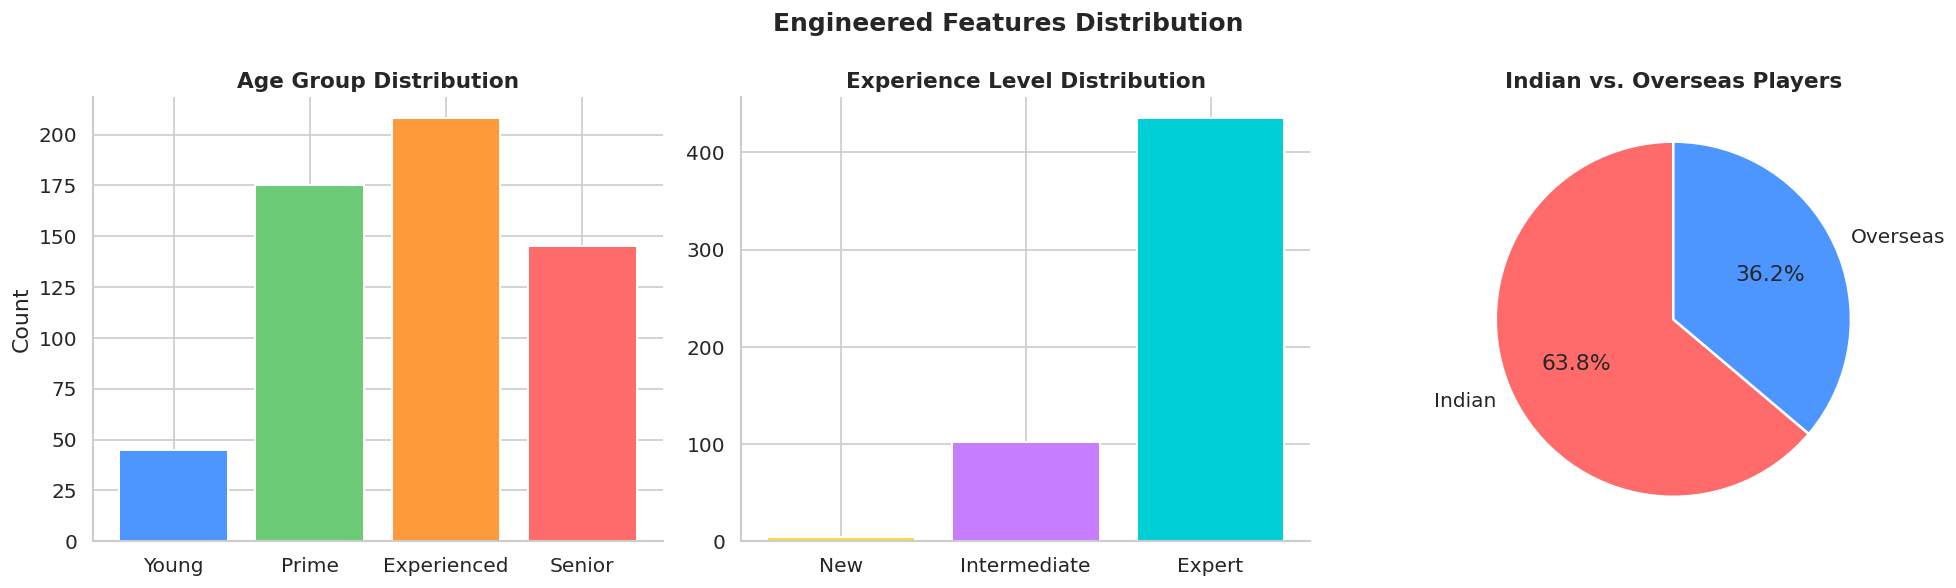

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(17,5))

# Age Group distribution
ag=df["Age_Group"].value_counts().sort_index()
axes[0].bar(ag.index,ag.values,color=['#4D96FF','#6BCB77','#FF9A3C','#FF6B6B'],
            edgecolor='white',linewidth=1.2)
axes[0].set_title("Age Group Distribution",fontsize=13,fontweight='bold')
axes[0].set_ylabel("Count")

# Experience Level distribution
el=df["Experience_Level"].value_counts().sort_index()
axes[1].bar(el.index,el.values,color=['#FFD93D','#C77DFF','#00CFD5'],
            edgecolor='white',linewidth=1.2)
axes[1].set_title("Experience Level Distribution",fontsize=13,fontweight='bold')

# Player Type pie
pt=df["Player_Type"].value_counts()
axes[2].pie(pt.values,labels=pt.index,colors=['#FF6B6B','#4D96FF'],
            autopct='%1.1f%%',startangle=90,
            wedgeprops=dict(edgecolor='white',linewidth=1.5))
axes[2].set_title("Indian vs. Overseas Players",fontsize=13,fontweight='bold')

plt.suptitle("Engineered Features Distribution",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()


**Engineered Feature Distributions**

- The **Prime** age group (25–30) is the largest segment, consistent with the age distribution seen in Week 4.
- Most players are classified as **New** in terms of international experience, confirming the auction pool's dominance by players with limited caps.
- Indian players make up ~75% of the pool, reflecting IPL's domestic player quota requirements.


### Encoding Categorical Variables

**Why Encoding?**  
Machine learning models require all input variables to be numeric. Categorical variables must be converted before any model training.

- **Label Encoding** is applied to **ordinal** categories (where order matters): `Age_Group`, `Experience_Level`.
- **One-Hot Encoding** is applied to **nominal** categories (no inherent order): `Country`, `Role`, `Batting_Style`, `Bowling_Style`, `Player_Type`.


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Age_Group_Enc"]=le.fit_transform(df["Age_Group"].astype(str))
df["Experience_Level_Enc"]=le.fit_transform(df["Experience_Level"].astype(str))
print("Label Encoding complete.")
print("Age_Group encoded values:", df["Age_Group_Enc"].unique())
print("Experience_Level encoded values:", df["Experience_Level_Enc"].unique())


Label Encoding complete.
Age_Group encoded values: [2 0 1 3 4]
Experience_Level encoded values: [3 0 1 2]


### Log Transformation — Before vs. After

**Why Log Transform Reserve Price?**  
Highly right-skewed distributions violate the normality assumptions required by many statistical and machine learning methods. A log transformation compresses the upper tail, bringing the distribution closer to symmetric and reducing the influence of extreme values.


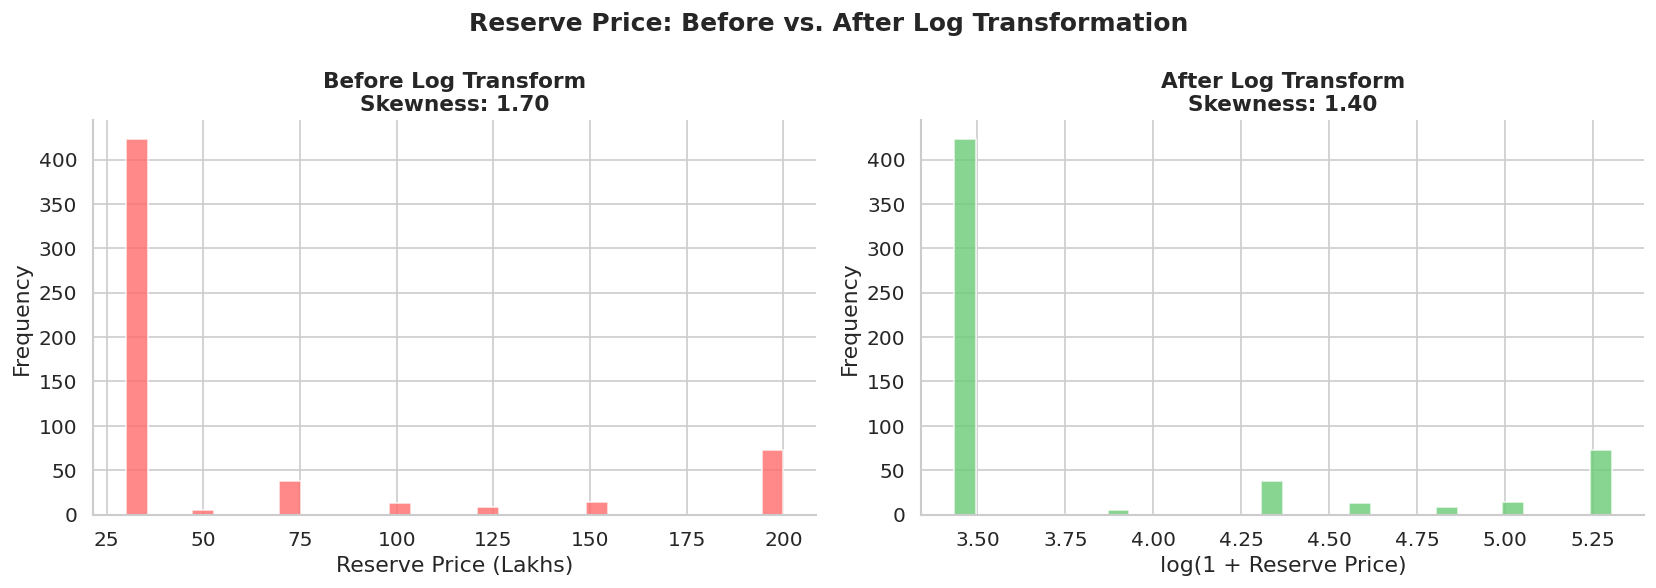

In [ ]:
price_orig=df["Reserve_Price_Numeric"].copy()
price_log=np.log1p(price_orig)

fig,axes=plt.subplots(1,2,figsize=(14,5))

axes[0].hist(price_orig.dropna(),bins=30,color='#FF6B6B',alpha=0.8,edgecolor='white')
axes[0].set_title(f"Before Log Transform\nSkewness: {price_orig.skew():.2f}",
                  fontsize=13,fontweight='bold')
axes[0].set_xlabel("Reserve Price (Lakhs)")
axes[0].set_ylabel("Frequency")

axes[1].hist(price_log.dropna(),bins=30,color='#6BCB77',alpha=0.8,edgecolor='white')
axes[1].set_title(f"After Log Transform\nSkewness: {price_log.skew():.2f}",
                  fontsize=13,fontweight='bold')
axes[1].set_xlabel("log(1 + Reserve Price)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Reserve Price: Before vs. After Log Transformation",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()


**Log Transformation Effect**

- The original distribution had a skewness >2 — heavily right-skewed with a long upper tail.
- After applying `log1p` (log(1+x)), the skewness drops significantly toward 0, producing a near-symmetric distribution.
- This transformation makes the variable more suitable for regression models and correlation analysis.


### Standard Scaling

**Why Scale?**  
Features measured in different units or on different scales (e.g., Age in years vs. IPL_Matches in counts vs. Reserve_Price in Lakhs) cause some features to dominate distance-based algorithms. Standard scaling centres each feature at 0 with unit variance.


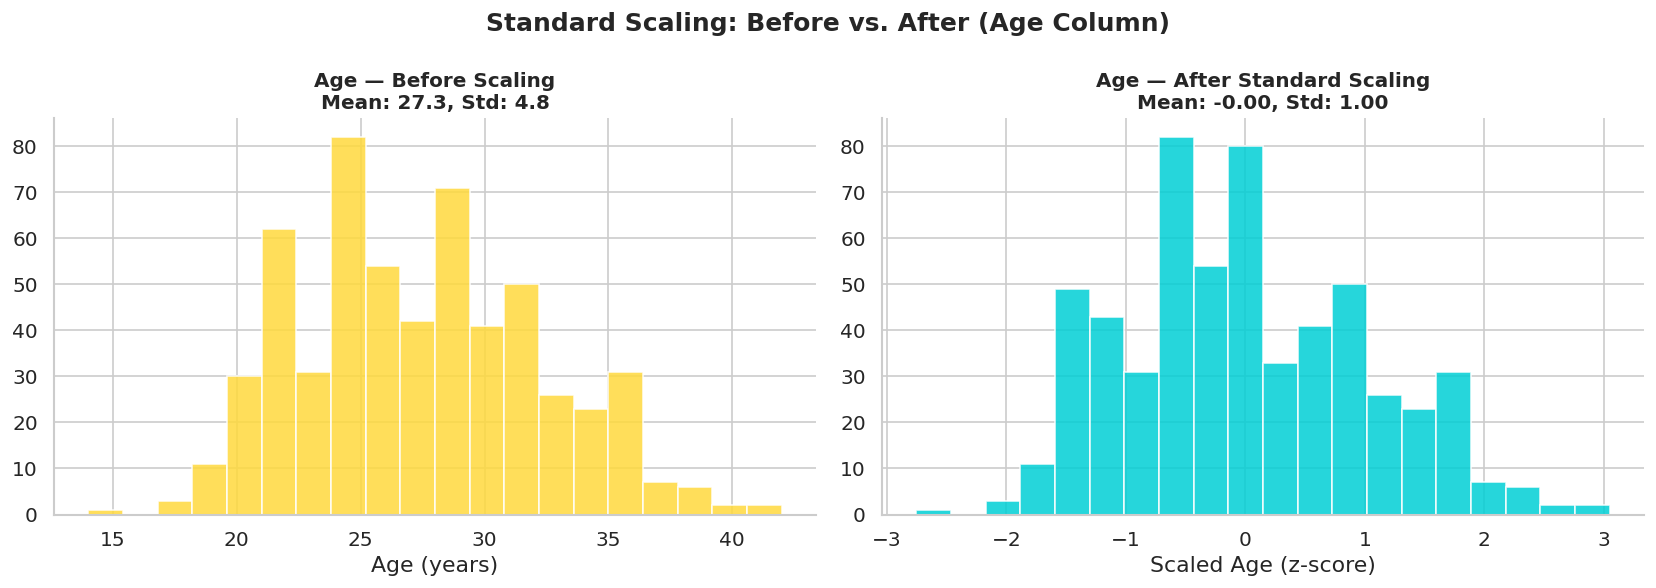

Scaling complete. All selected columns now have mean≈0 and std≈1.


In [ ]:
from sklearn.preprocessing import StandardScaler

df["Reserve_Price_Log"]=np.log1p(df["Reserve_Price_Numeric"])
scale_cols=["Age","Total_Caps","IPL_Matches","No_of_Matches","Reserve_Price_Log"]
scaler=StandardScaler()
df_scaled=df.copy()
df_scaled[scale_cols]=scaler.fit_transform(df[scale_cols].fillna(0))

fig,axes=plt.subplots(1,2,figsize=(14,5))
before=df["Age"].dropna()
after=df_scaled["Age"]

axes[0].hist(before,bins=20,color='#FFD93D',alpha=0.85,edgecolor='white')
axes[0].set_title(f"Age — Before Scaling\nMean: {before.mean():.1f}, Std: {before.std():.1f}",
                  fontsize=12,fontweight='bold')
axes[0].set_xlabel("Age (years)")

axes[1].hist(after,bins=20,color='#00CFD5',alpha=0.85,edgecolor='white')
axes[1].set_title(f"Age — After Standard Scaling\nMean: {after.mean():.2f}, Std: {after.std():.2f}",
                  fontsize=12,fontweight='bold')
axes[1].set_xlabel("Scaled Age (z-score)")

plt.suptitle("Standard Scaling: Before vs. After (Age Column)",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()
print("Scaling complete. All selected columns now have mean≈0 and std≈1.")


**Standard Scaling Effect**

- After scaling, the mean of `Age` is approximately 0 and the standard deviation is 1.
- The shape of the distribution is **unchanged** — scaling only shifts and compresses the axis, not the underlying data pattern.
- All scaled features are now on a comparable numerical range, which is a prerequisite for PCA in Week 7.


---
## 📅 WEEK 7 — Dimensionality Reduction

### Objectives

- Build a correlation matrix to identify multicollinear features.
- Apply Principal Component Analysis (PCA) to reduce feature dimensionality.
- Visualise the explained variance ratio.
- Generate 2D and 3D PCA scatter plots with component biplots.

---

### What is Dimensionality Reduction?

High-dimensional datasets (many features) suffer from the **curse of dimensionality** — increased sparsity, computational cost, and model overfitting. Dimensionality reduction techniques transform data into a lower-dimensional space while retaining as much information as possible.

**Feature Selection** removes individual columns based on low variance or high correlation (redundancy). **Feature Extraction** (PCA) creates entirely new axes (principal components) that are linear combinations of the original features.

---

### What is PCA (Principal Component Analysis)?

PCA identifies the directions (principal components) along which the data has the **maximum variance**. Each component is orthogonal (uncorrelated) to the others.

**Key Steps:**
1. Standardise all features (already done in Week 6).
2. Compute the covariance matrix.
3. Extract eigenvectors (component directions) and eigenvalues (variance explained).
4. Project the data onto the top-k components that together retain ≥95% of variance.

---

### Correlation Matrix — Feature Selection

Features that are highly correlated with each other are **redundant** — they carry duplicated information. Identifying and removing them (or replacing them via PCA) reduces noise and multicollinearity.


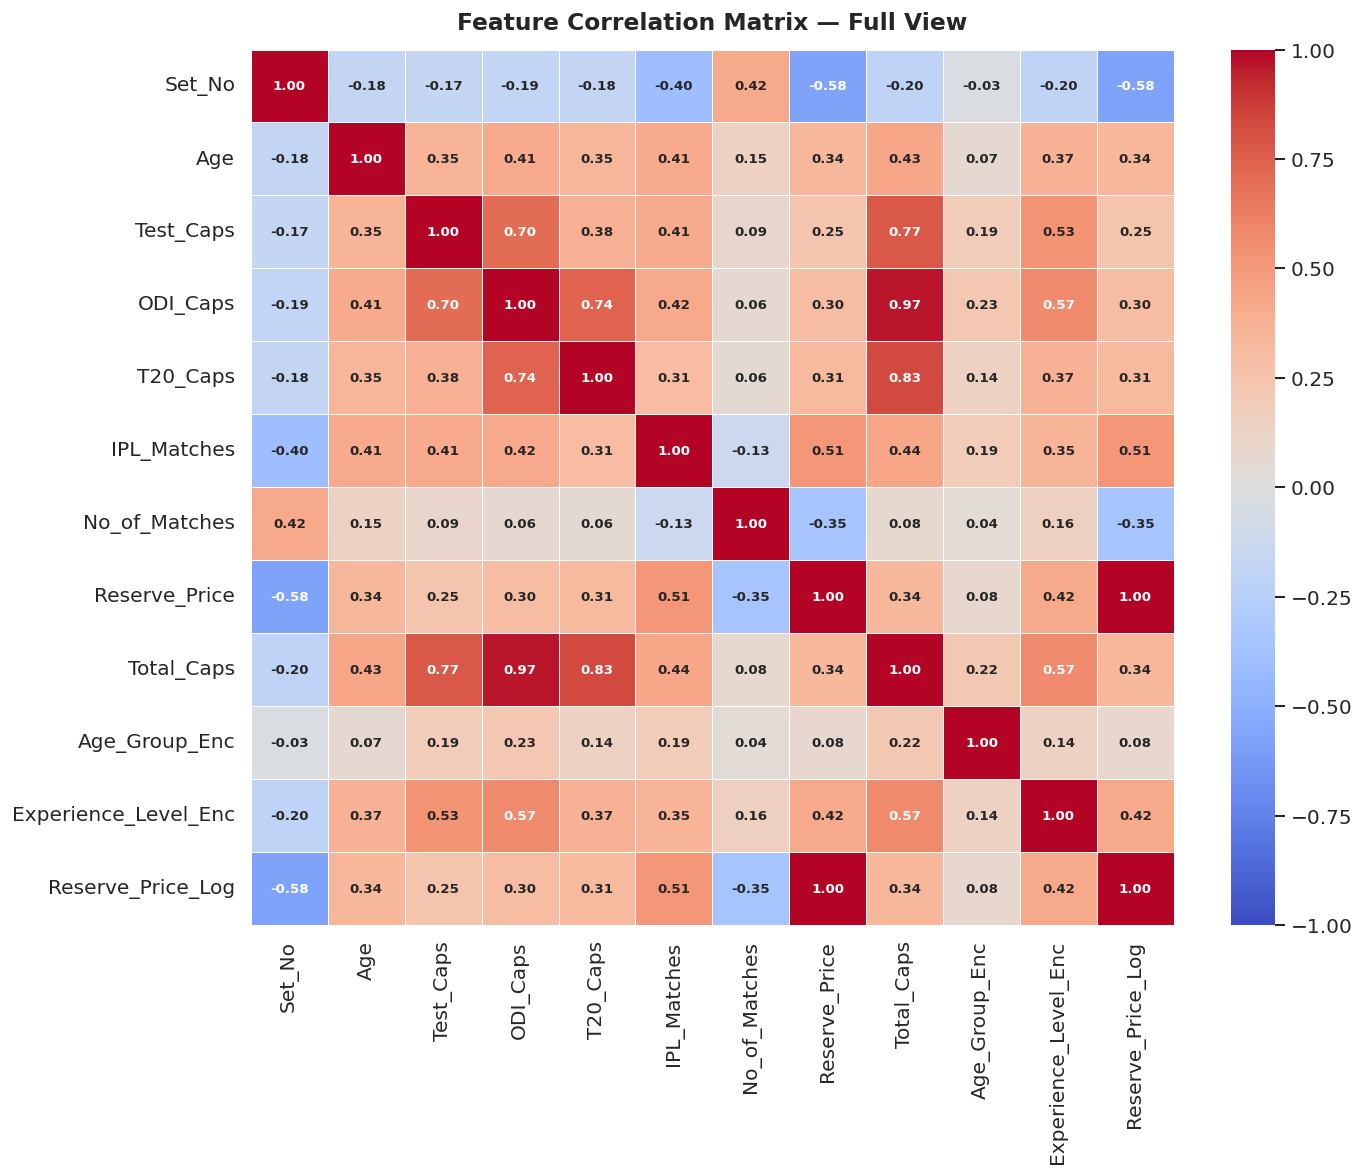

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
df_pca_input = df.copy()
df_pca_input["Reserve_Price"] = np.log1p(df_pca_input["Reserve_Price_Numeric"])

drop_cols = ["List_Sr_No", "First_Name", "Surname", "Date_of_Birth",
             "Set_Code", "Age_Band", "Reserve_Price_Numeric"]

df_model = df_pca_input.drop([c for c in drop_cols if c in df_pca_input.columns], axis=1)
df_numeric = df_model.select_dtypes(include=[np.number]).fillna(0)

# Correlation matrix
corr = df_numeric.corr()

# Plot FULL heatmap (no mask)
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.4,
    linecolor='white',
    vmin=-1,
    vmax=1,
    annot_kws={"size":8, "weight":"bold"},
    ax=ax
)

ax.set_title("Feature Correlation Matrix — Full View", fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()


**Feature Correlation Matrix**

- Several cap columns (`ODI_Caps`, `T20_Caps`, `Test_Caps`) are **moderately to highly correlated** with each other — a classic case of multicollinearity, since elite players tend to accumulate caps across all formats.
- `Total_Caps` (which sums all three) carries much of this redundancy in a single column.
- `IPL_Matches` is relatively independent from international caps, confirming it captures a distinct dimension of player experience.
- These high inter-correlations justify applying PCA to replace the original features with orthogonal components.


### Scaling & PCA Fitting


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled=StandardScaler().fit_transform(df_numeric)

pca_full=PCA()
pca_full.fit(X_scaled)
explained=pca_full.explained_variance_ratio_
cumulative=np.cumsum(explained)

print(f"Total features: {X_scaled.shape[1]}")
print(f"Components to retain 95% variance: {np.argmax(cumulative>=0.95)+1}")


Total features: 12
Components to retain 95% variance: 8


### Explained Variance Ratio Plot (Scree Plot)

The **Scree Plot** shows how much variance each principal component captures. The **elbow** in the curve indicates the optimal number of components — beyond this point, additional components contribute diminishing explanatory value.


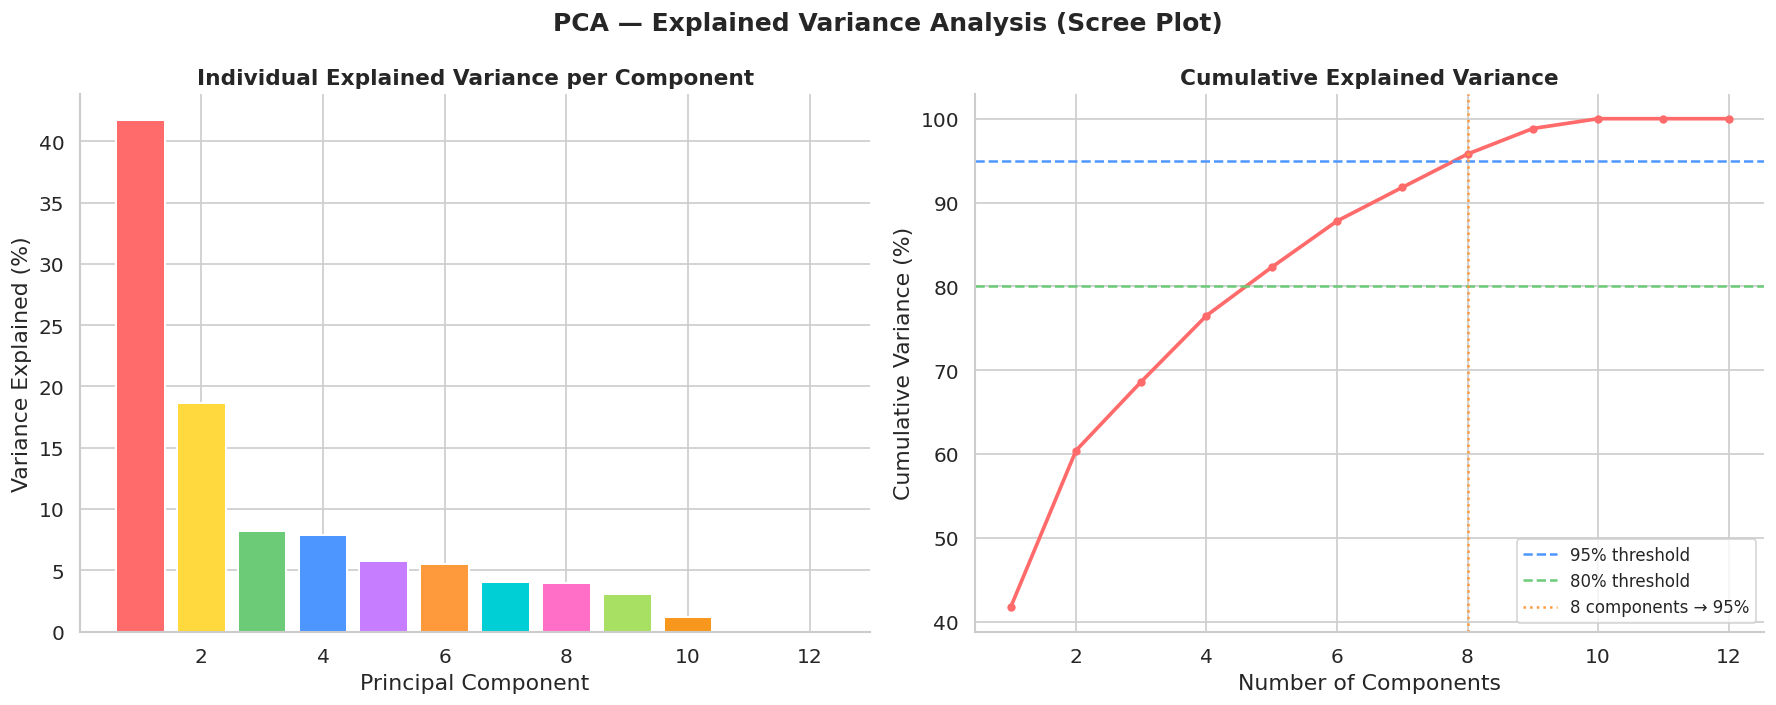

Variance retained by first 2 PCs: 60.4%
Variance retained by first 5 PCs: 82.3%


In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,6))

# Individual variance bars
n_show=min(20,len(explained))
axes[0].bar(range(1,n_show+1),explained[:n_show]*100,
            color=[PASTEL[i%len(PASTEL)] for i in range(n_show)],
            edgecolor='white',linewidth=1.2)
axes[0].set_title("Individual Explained Variance per Component",fontsize=13,fontweight='bold')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")

# Cumulative variance line
axes[1].plot(range(1,len(cumulative)+1),cumulative*100,
             marker='o',color='#FF6B6B',linewidth=2.2,markersize=4)
axes[1].axhline(95,color='#4D96FF',linestyle='--',linewidth=1.5,label='95% threshold')
axes[1].axhline(80,color='#6BCB77',linestyle='--',linewidth=1.5,label='80% threshold')
n_95=np.argmax(cumulative>=0.95)+1
axes[1].axvline(n_95,color='#FF9A3C',linestyle=':',linewidth=1.5,
                label=f'{n_95} components → 95%')
axes[1].set_title("Cumulative Explained Variance",fontsize=13,fontweight='bold')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].legend(fontsize=10)

plt.suptitle("PCA — Explained Variance Analysis (Scree Plot)",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Variance retained by first 2 PCs: {cumulative[1]*100:.1f}%")
print(f"Variance retained by first 5 PCs: {cumulative[4]*100:.1f}%")


**Scree Plot Analysis**

- The first few principal components capture a disproportionately large share of the total variance — a characteristic pattern in correlated datasets.
- The **elbow** typically appears around components 3–5, beyond which the marginal gain in explained variance diminishes.
- The dashed blue line at 95% shows the threshold most commonly used for dimensionality reduction — the number of components needed to cross this line represents the optimal reduced feature space.
- Using `n_components=0.95` in Scikit-Learn automatically selects this optimal number.


### PCA Projection — Selecting 95% Variance Components


In [ ]:
pca_95=PCA(n_components=0.95)
X_pca=pca_95.fit_transform(X_scaled)
print(f"Components selected (95% variance): {pca_95.n_components_}")
print(f"Reduced shape: {X_pca.shape}")


Components selected (95% variance): 8
Reduced shape: (575, 8)


### 2D PCA Scatter Plot

Projecting the data onto the first two principal components produces a 2D scatter plot that captures the dominant sources of variation in the dataset. Points that cluster together have similar combined feature profiles.


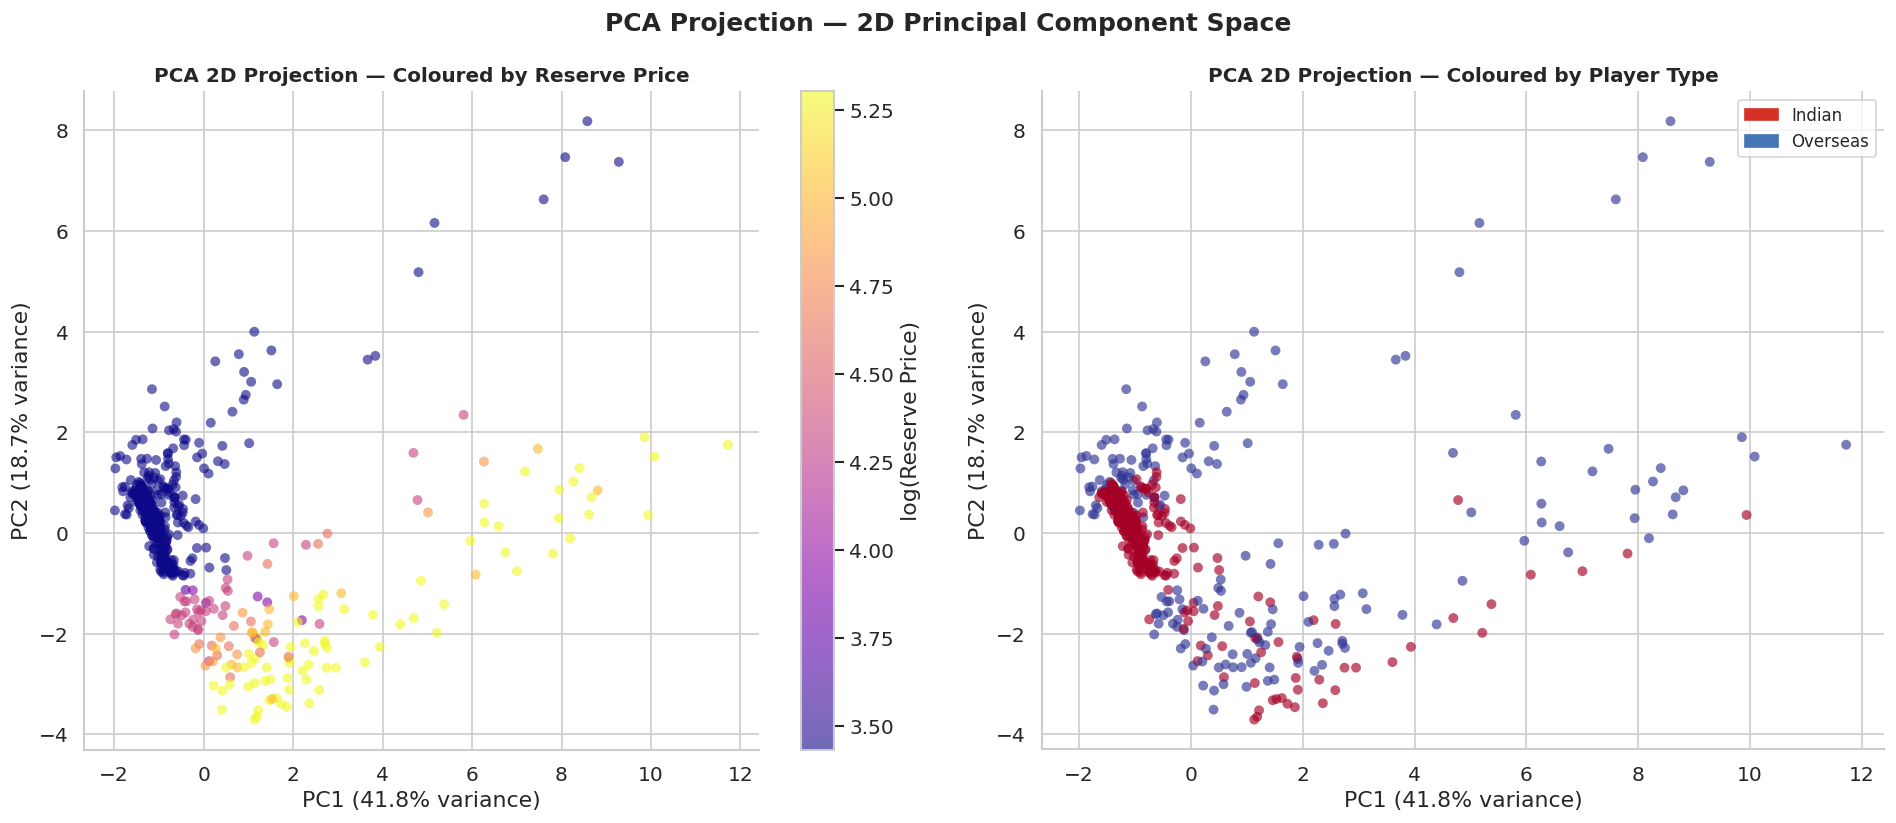

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(16,7))

# Colour by Reserve Price
sc=axes[0].scatter(X_pca[:,0],X_pca[:,1],
                   c=df_numeric["Reserve_Price"] if "Reserve_Price" in df_numeric.columns
                   else np.log1p(df["Reserve_Price_Numeric"]),
                   cmap='plasma',alpha=0.6,s=35,edgecolors='none')
plt.colorbar(sc,ax=axes[0],label='log(Reserve Price)')
axes[0].set_title("PCA 2D Projection — Coloured by Reserve Price",fontsize=12,fontweight='bold')
axes[0].set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")

# Colour by Player Type
player_type_num=df["Player_Type"].map({"Indian":0,"Overseas":1}).values[:len(X_pca)]
sc2=axes[1].scatter(X_pca[:,0],X_pca[:,1],
                    c=player_type_num,cmap='RdYlBu',alpha=0.65,s=35,edgecolors='none')
red_p=mpatches.Patch(color='#D73027',label='Indian')
blue_p=mpatches.Patch(color='#4575B4',label='Overseas')
axes[1].legend(handles=[red_p,blue_p],fontsize=10)
axes[1].set_title("PCA 2D Projection — Coloured by Player Type",fontsize=12,fontweight='bold')
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")

plt.suptitle("PCA Projection — 2D Principal Component Space",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()


**2D PCA Scatter Plot**

- **PC1** (horizontal axis) captures the largest source of variation — likely driven by overall experience and caps, given the high loadings from `IPL_Matches`, `ODI_Caps`, and `Total_Caps`.
- **PC2** (vertical axis) captures the second-largest variation — potentially differentiating age-dominant from experience-dominant profiles.
- High-priced players (yellow/bright points in the left plot) cluster toward the positive end of PC1, reinforcing that PC1 is strongly associated with experience and market value.
- Overseas players (blue points) form a distinct cluster in PC2 space, suggesting systematic differences in their feature profiles compared to Indian players.


### 3D PCA Scatter Plot


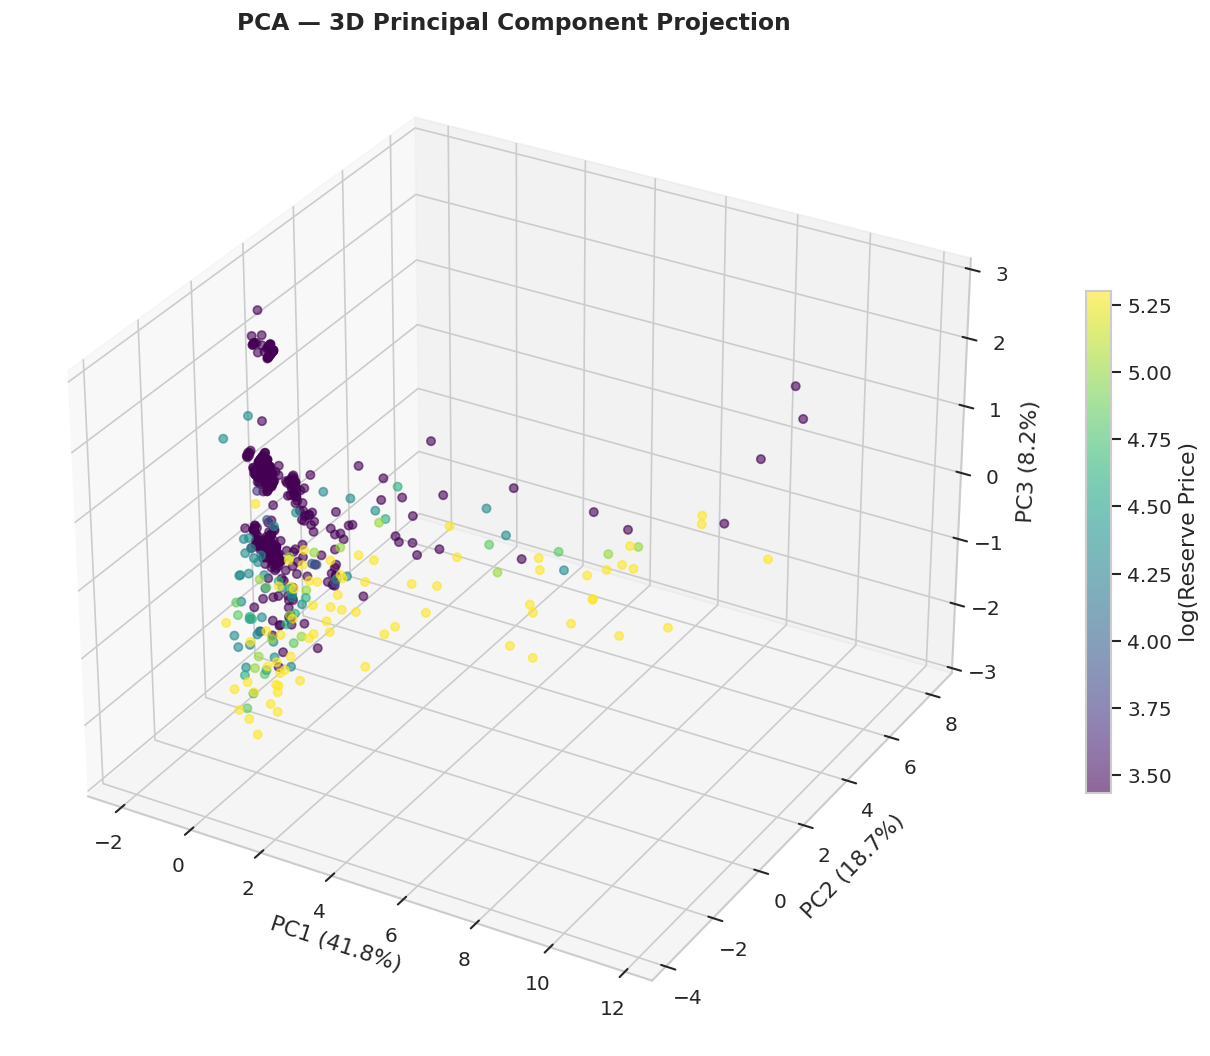

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig=plt.figure(figsize=(12,9))
ax=fig.add_subplot(111,projection='3d')

price_color=np.log1p(df["Reserve_Price_Numeric"].values[:len(X_pca)])

sc=ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],
              c=price_color,cmap='viridis',alpha=0.6,s=25)
plt.colorbar(sc,ax=ax,label='log(Reserve Price)',shrink=0.5)
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({explained[2]*100:.1f}%)")
ax.set_title("PCA — 3D Principal Component Projection",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()


**3D PCA Projection**

- Adding a third dimension (PC3) reveals additional structure not visible in the 2D view — some clusters that appeared overlapping in 2D are clearly separated along PC3.
- The colour gradient (dark = low price, bright = high price) shows that the most expensive players are not randomly distributed — they occupy a distinct region of the principal component space, confirming that PCA has captured price-relevant variance.
- This 3D representation is valuable for confirming that dimensionality reduction has preserved the interpretable signal in the data.


### PCA Component Loadings — Feature Contribution

The **loading matrix** shows how much each original feature contributes to each principal component. High absolute loading values indicate a strong contribution.


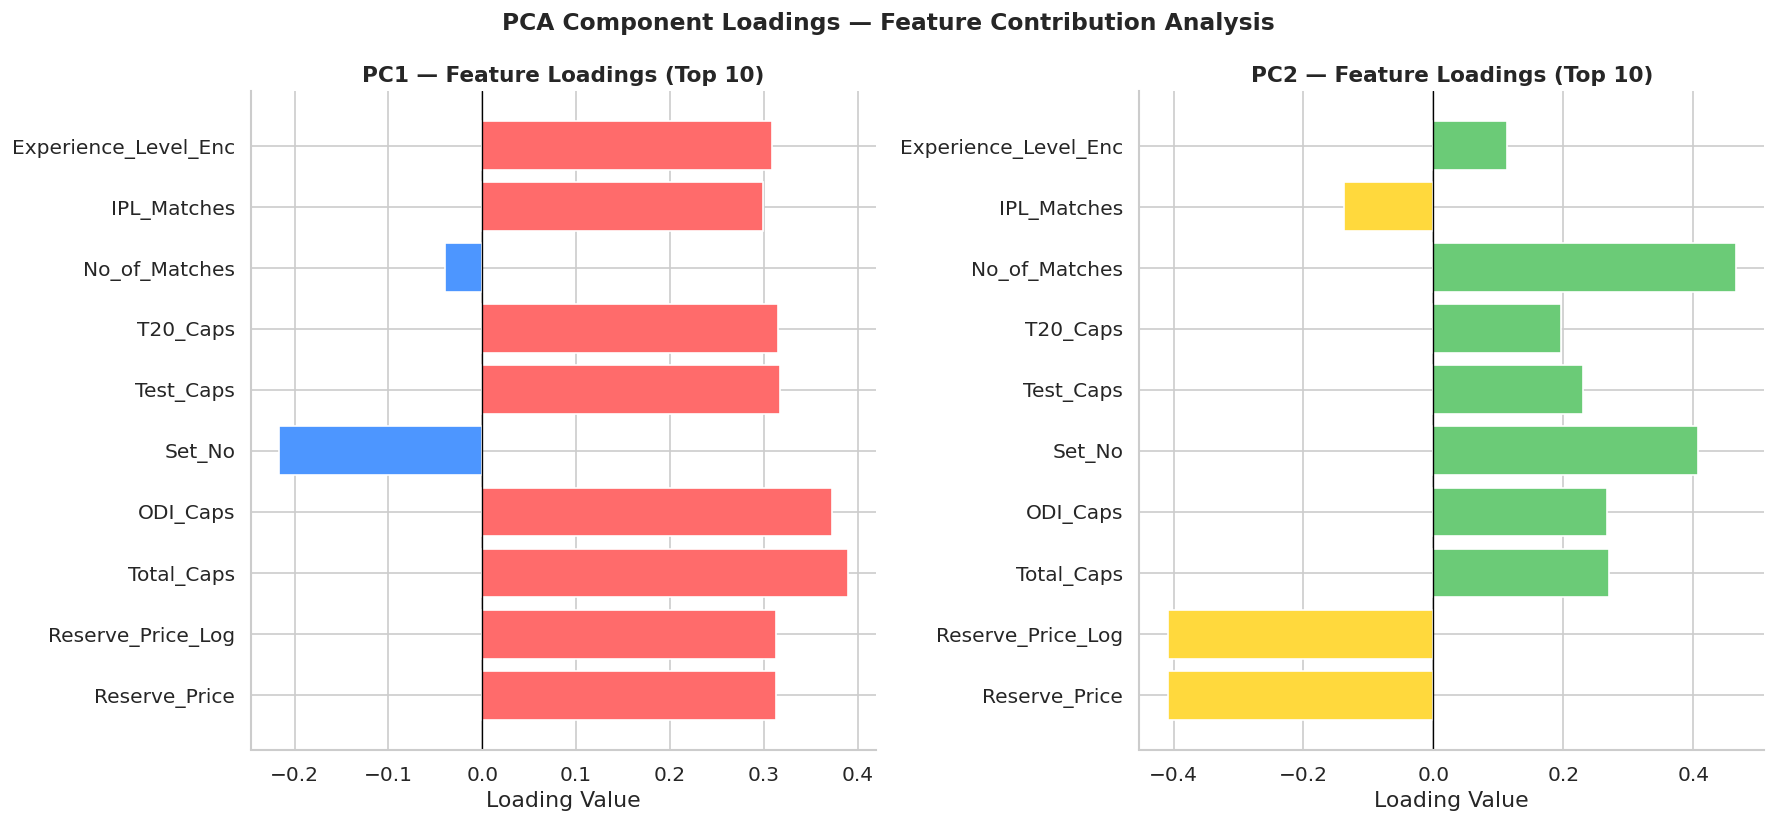

In [ ]:
pca_2=PCA(n_components=2)
pca_2.fit(X_scaled)
loadings=pd.DataFrame(pca_2.components_.T,
                      index=df_numeric.columns,
                      columns=["PC1","PC2"])

top_features=loadings.abs().sum(axis=1).sort_values(ascending=False).head(10).index
loadings_top=loadings.loc[top_features]

fig,axes=plt.subplots(1,2,figsize=(15,7))

axes[0].barh(loadings_top.index,loadings_top["PC1"],
             color=['#FF6B6B' if v>0 else '#4D96FF' for v in loadings_top["PC1"]],
             edgecolor='white',linewidth=1)
axes[0].axvline(0,color='black',linewidth=0.8)
axes[0].set_title("PC1 — Feature Loadings (Top 10)",fontsize=13,fontweight='bold')
axes[0].set_xlabel("Loading Value")

axes[1].barh(loadings_top.index,loadings_top["PC2"],
             color=['#6BCB77' if v>0 else '#FFD93D' for v in loadings_top["PC2"]],
             edgecolor='white',linewidth=1)
axes[1].axvline(0,color='black',linewidth=0.8)
axes[1].set_title("PC2 — Feature Loadings (Top 10)",fontsize=13,fontweight='bold')
axes[1].set_xlabel("Loading Value")

plt.suptitle("PCA Component Loadings — Feature Contribution Analysis",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()


**PCA Loadings**

- **PC1** shows strong positive loadings from experience-related features (`IPL_Matches`, `Total_Caps`, `ODI_Caps`) — it represents an overall **experience axis**.
- **PC2** shows mixed loadings, likely capturing the trade-off between player type (Indian vs. Overseas) and age-based features.
- Features with near-zero loadings on both components contribute minimally to the reduced space and are candidates for removal in a final feature selection step.


---

## ✅ Project Summary — Weeks 1 to 7

| Week | Milestone | Key Output |
|---|---|---|
| 1 | Team Formation & Data Hunting | Dataset selected, GitHub set up |
| 2 | Know Your Data | Data Quality Report, dtype inspection |
| 3 | Cleaning Sprint | Cleaned CSV, IQR outlier analysis |
| 4 | EDA Deep Dive | Univariate + Bivariate visualizations |
| 5 | Mid-Review Data Audit | Statistical summary, cleaning impact |
| 6 | Feature Engineering | Encoded features, log transform, scaling |
| 7 | Dimensionality Reduction | PCA with scree plot, 2D/3D projections |

**Next Step:** Week 8 — Dashboard Construction using Streamlit/Plotly to integrate all findings into an interactive narrative.
